# Project 5. Machine Learning for Regression Task

## 1. Problem Statement

**Project Overview**

This project addresses a real-world machine learning task aimed at automating business processes. A model will be built to predict the total duration of taxi trips in New York.

Imagine ordering a taxi from one point in New York to another, where the destination may not necessarily be within the city limits. How much would the trip cost? It is known that taxi fares in the U.S. are calculated based on a fixed rate plus a variable fare, which depends on time and distance. Fares vary by city.

Trip duration, in turn, depends on numerous factors, such as the starting and ending points, the time of day, weather conditions, and more.

Thus, by developing an algorithm capable of determining trip duration, the fare can be predicted in a straightforward manner, for example, by multiplying the duration by a given rate. Taxi services store vast amounts of trip data, including details such as starting and ending points, trip date, and duration. These data can be leveraged to predict trip duration automatically using artificial intelligence.

**Business Task:** 

Identify characteristics and use them to forecast the duration of a taxi trip.

**Technical Task for a Data Science Specialist:** 

Build a machine learning model that predicts a numerical feature — taxi trip duration — based on provided client characteristics, solving a regression task.

**Project Objectives:**

1. `Form a dataset by combining multiple information sources`.

2. `Engineering new features using Feature Engineering and identify the most significant ones for model building`.

3. `Explore the provided data and uncover patterns`.

4. `Build multiple models and select the best one based on a specified metric`.

5. `Design a process for predicting trip duration for new data`.

The solution will be submitted to the Kaggle platform, participating in a Data Science competition. The project will hone skills in handling multiple data sources, feature engineering, exploratory data analysis, visualization, feature selection, and building machine learning models.


## 2. Data Familiarization, Basic Analysis, and Data Enrichment

Begin with exploring the provided data. Additional data sources will be loaded to expand the initial dataset

Necessary modules will be imported in advance for solving the task:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline
plt.style.use('seaborn-v0_8')

from comet_ml import Experiment
from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import OneHotEncoder

In [2]:
#@title CometML set up

#project_name = 'project_name'
#workspace = 'workspace_name'
#api_key = 'api_key_here'

In [3]:
# Start the experiment

# experiment = Experiment(project_name=project_name, workspace=workspace, api_key = api_key, log_code=True)

The file with the initial data will be read:

In [4]:
# Load the data

taxi_data = pd.read_csv("data/train.csv")
print('Train data shape: {}'.format(taxi_data.shape))
taxi_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


The dataset contains information on nearly 1.5 million trips and 11 characteristics describing each trip.

The features are conditionally divided into several groups, each of which will receive focused attention later.

**Client and Taxi Company Data:**

- `id`: Unique trip identifier.

- `vendor_id`: Unique identifier of the taxi company associated with the trip record.

**Temporal Characteristics:**

- `pickup_datetime`: Date and time when the trip meter was activated.

- `dropoff_datetime`: Date and time when the trip meter was deactivated.

**Geographical Information:**

- `pickup_longitude`: Longitude where the trip meter was activated.

- `pickup_latitude`: Latitude where the trip meter was activated.

- `dropoff_longitude`: Longitude where the trip meter was deactivated.

- `dropoff_latitude`: Latitude where the trip meter was deactivated.

**Other Features:**

- `passenger_count`: Number of passengers in the vehicle (driver-entered value).

- `store_and_fwd_flag`: Flag indicating whether the trip record was stored in the vehicle’s memory before being sent to the vendor. Y - store and forward, N - do not store or forward.

**Target Feature:**

- `trip_duration`: Trip duration in seconds.


A basic analysis will be conducted to assess how ready the data is for further preprocessing and analysis.

The temporal scope of the data will be examined first.

The `pickup_datetime` feature will be converted to a datetime type with the format year-month-day hour:minute:second (using `pd.to_datetime()` with the parameter `format='%Y-%m-%d %H:%M:%S'`).

The temporal range (excluding time) covered by the data will be determined.

In [5]:
# Convert the pickup_datetime feature to datetime type

taxi_data['pickup_datetime'] = pd.to_datetime(taxi_data['pickup_datetime'])
min_date = taxi_data['pickup_datetime'].min()
max_date = taxi_data['pickup_datetime'].max()
print(f'Data collected from {min_date} to {max_date}')

Data collected from 2016-01-01 00:00:17 to 2016-06-30 23:59:39


Missing values will be examined.
The total number of missing values across all table columns will be calculated.

In [6]:
# Investigate missing values in the data

taxi_data.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

- There are no missing values in the data.

Statistical characteristics of some features will be analyzed.

a) The number of unique taxi companies in the data will be determined.

b) The maximum number of passengers will be identified.

c) The mean and median trip duration will be calculated, rounded to the nearest integer in seconds.

d) The minimum and maximum trip durations (in seconds) will be determined.


In [7]:
# Examine basic statistical characteristics

taxi_data.describe().round().T

,count,mean,min,25%,50%,75%,max,std
vendor_id,1458644.0,2.0,1.0,1.0,2.0,2.0,2.0,0.0
pickup_datetime,1458644,2016-04-01 10:10:24.940037120,2016-01-01 00:00:17,2016-02-17 16:46:04.249999872,2016-04-01 17:19:40,2016-05-15 03:56:08.750000128,2016-06-30 23:59:39,NaN
passenger_count,1458644.0,2.0,0.0,1.0,1.0,2.0,9.0,1.0
pickup_longitude,1458644.0,-74.0,-122.0,-74.0,-74.0,-74.0,-61.0,0.0
pickup_latitude,1458644.0,41.0,34.0,41.0,41.0,41.0,52.0,0.0
dropoff_longitude,1458644.0,-74.0,-122.0,-74.0,-74.0,-74.0,-61.0,0.0
dropoff_latitude,1458644.0,41.0,32.0,41.0,41.0,41.0,44.0,0.0
trip_duration,1458644.0,959.0,1.0,397.0,662.0,1075.0,3526282.0,5237.0


### Key Observations:

- The data includes 2 unique taxi companies.

- The maximum number of passengers per trip is 9.

- The average trip duration is 959 seconds, and the median is 662 seconds.

- The minimum and maximum trip durations are 1 and 3,526,282 seconds, respectively.


The initial dataset will be expanded using external sources and manipulations with existing features.


A function `add_datetime_features()` will be implemented, which takes a DataFrame with trip data as input and returns the same DataFrame with three additional columns:

- `pickup_date`: Date when the trip meter was activated (without time).

- `pickup_hour`: Hour of the day when the trip meter was activated.

- `pickup_day_of_week`: Ordinal number of the day of the week (number) when the trip meter was activated.

a) The number of trips made on Saturdays will be calculated.

b) The average number of trips per day will be computed, rounded to the nearest integer.

In [8]:
# Implement the add_datetime_features() function to add additional data to the dataset

def add_datetime_features(df):
    """
    Function adds features to the DataFrame that may be useful for time series analysis.

    Args:
        dataframe (pd.DataFrame): DataFrame to which new features will be added.

    Returns:
        dataframe (pd.DataFrame): DataFrame with added features.
    """
    
    df['pickup_date'] = pd.to_datetime(df['pickup_datetime']).dt.date
    df['pickup_hour'] = pd.to_datetime(df['pickup_datetime']).dt.hour
    df['pickup_day_of_week'] = pd.to_datetime(df['pickup_datetime']).dt.dayofweek
    return df

# Apply the function to the dataset

taxi_data = add_datetime_features(taxi_data)

In [9]:
# Verify that new features have been added to the dataset

saturday_rides = taxi_data[taxi_data['pickup_day_of_week'] == 5]['id'].count()
avg_rides_count = taxi_data.groupby('pickup_date')['id'].count().sum() / taxi_data['pickup_date'].nunique()

print(f'Trips made on Saturday: {saturday_rides}')
print(f'On average, {round(avg_rides_count)} trips are made per day')

Trips made on Saturday: 220868
On average, 8015 trips are made per day


A function `add_holiday_features()` will be implemented, which takes two tables as input:

- A table with trip data.

- A table with holiday data.

The function returns an updated trip data table with an added column `pickup_holiday` — a binary feature indicating whether the trip started on a holiday (1 - yes, 0 - no).

The median trip duration on holidays will be calculated, rounded to the nearest integer in seconds.


In [ ]:
# Load an additional dataset with U.S. holidays and create new features based on it

holiday_data = pd.read_csv('data/holiday_data.csv', sep=';')
holiday_data.head()

,day,date,holiday
0,Friday,2016-01-01,New Years Day
1,Monday,2016-01-18,Martin Luther King Jr. Day
2,Friday,2016-02-12,Lincoln's Birthday
3,Monday,2016-02-15,Presidents' Day
4,Sunday,2016-05-08,Mother's Day


In [11]:
# Create a function to merge datasets and generate the pickup_holiday feature

def add_holiday_features(df, holiday_df):
    """
    Function adds a pickup_holiday feature to the DataFrame, indicating whether the day is a holiday.

    Args:
        dataframe (pd.DataFrame): DataFrame to which the new feature will be added.
        holiday_df (pd.DataFrame): DataFrame with holiday data used to create the new feature.

    Returns:
        dataframe (pd.DataFrame): DataFrame with the added pickup_holiday feature.
    """
    holiday_df['pickup_date'] = pd.to_datetime(holiday_df['date']).dt.date
    holiday_df['pickup_holiday'] = 1
    df = df.merge(
        holiday_df[['pickup_date','pickup_holiday']],
        how='left',
        on='pickup_date'      
    )
    df['pickup_holiday'] = df['pickup_holiday'].fillna(0).astype(int)
    return df

taxi_data = add_holiday_features(taxi_data, holiday_data)


In [12]:
# Calculate the median trip duration on holidays

holiday_median_ride = taxi_data[taxi_data['pickup_holiday'] == 1]['trip_duration'].median()
print(f'Median trip duration on holidays: {round(holiday_median_ride)} seconds')

Median trip duration on holidays: 585 seconds


A function `add_osrm_features()` will be implemented, which takes two tables as input:

- A table with trip data.

- A table with OSRM data.

The function returns an updated trip data table with three additional columns:

- `total_distance`

- `total_travel_time`

- `number_of_steps`

a) The difference (in seconds) between the median trip duration in the original data and the median trip duration from OSRM will be calculated.

After merging the tables, missing values may appear in the columns with OSRM API information due to the inability to retrieve data for some trips from the web source.

b) The number of missing values in the OSRM API columns after merging the tables will be determined.

In [13]:
# Load trip data from OSRM

osrm_data = pd.read_csv('data/osrm_data_train.csv')
osrm_data.head(1)

,id,starting_street,end_street,total_distance,total_travel_time,number_of_steps,street_for_each_step,distance_per_step,travel_time_per_step,step_maneuvers,step_direction,step_location_list
0,id2875421,Columbus Circle,East 65th Street,2009.1,164.9,5,Columbus Circle|Central Park West|65th Street ...,0|576.4|885.6|547.1|0,0|61.1|60.1|43.7|0,depart|rotary|turn|new name|arrive,left|straight|right|straight|arrive,"-73.982316,40.767869|-73.981997,40.767688|-73...."


In [14]:
# Create a function to add new features from the OSRM dataset to the dataset

def add_osrm_features(df, osrm_df):
    """
    Function adds OSRM features to the DataFrame that may be useful for time series analysis.

    Args:
        dataframe (pd.DataFrame): DataFrame to which new features will be added.
        dataframe (pd.DataFrame): DataFrame with OSRM data used to create new features.

    Returns:
        dataframe (pd.DataFrame): DataFrame with added features.
    """
    df = df.merge(
        osrm_df[['id','total_distance', 'total_travel_time', 'number_of_steps']],
        how='left',
        on='id'
    )
    return df

taxi_data = add_osrm_features(taxi_data, osrm_data)

In [15]:
# Verify that new features have been added to the dataset

median_diff = taxi_data['trip_duration'].median() - taxi_data['total_travel_time'].median()
print(f'Difference between median trip durations in original and OSRM data: {round(median_diff)} seconds')

Difference between median trip durations in original and OSRM data: 372 seconds


In [16]:
# Examine missing values in the data

column_to_check = ['total_distance', 'total_travel_time', 'number_of_steps']
taxi_data[column_to_check].isnull().sum()

total_distance       1
total_travel_time    1
number_of_steps      1
dtype: int64

- After merging the data, there is only 1 missing value.

In [17]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    """
    Function calculates the distance between two points on the Earth's surface based on their coordinates.

    Args:
        float lat1: Latitude of the first point in degrees.
        float lng1: Longitude of the first point in degrees.
        float lat2: Latitude of the second point in degrees.
        float lng2: Longitude of the second point in degrees.

    Returns:
        float: Distance between the two points in kilometers.
    """
    # Convert angles to radians
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # Earth's radius in kilometers
    EARTH_RADIUS = 6371 
    # Calculate the shortest distance h using the Haversine formula
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    """
    Function calculates the bearing angle between two points on the Earth's surface based on their coordinates.

    Args:
        float lat1: Latitude of the first point in degrees.
        float lng1: Longitude of the first point in degrees.
        float lat2: Latitude of the second point in degrees.
        float lng2: Longitude of the second point in degrees.

    Returns:
        float: Bearing angle in degrees.
    """
    # Convert angles to radians
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # Calculate the bearing angle alpha using the bearing formula
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

A function `add_geographical_features()` will be implemented, which takes a table with trip data as input and returns an updated table with two additional columns:

- `haversine_distance`: Haversine distance between the point where the trip meter was activated and the point where it was deactivated.

- `direction`: Direction of movement from the point where the trip meter was activated to the point where it was deactivated.

The median Haversine distance of trips (in kilometers) will be calculated


In [18]:
# Create a function to add additional geographical features

def add_geographical_features(df):
    """
    Function calculates the Haversine distance and bearing angle between two points on the Earth's surface based on their coordinates.

    Args:
        dataframe (pd.DataFrame): DataFrame to which new features will be added.

    Returns:
        dataframe (pd.DataFrame): DataFrame with added features.
    """
    df['haversine_distance'] = get_haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
    df['direction'] = get_angle_direction(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
    return df

# Add the features

taxi_data = add_geographical_features(taxi_data)

In [19]:
# Verify that new features have been added to the dataset

haversine_median = taxi_data['haversine_distance'].median()
print(f'Median Haversine distance: {round(haversine_median, 2)} kilometers')

Median Haversine distance: 2.09 kilometers


A function `add_cluster_features()` will be implemented, which takes a table with trip data and a trained clustering algorithm as input. The function will return an updated table with an added column `geo_cluster` — the geographical cluster to which the trip belongs.

The number of trips in the smallest geographical cluster will be determined.

In [20]:
# Create a training set from the geographical coordinates of all points

coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))

# Train the clustering algorithm

kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

# Create a function to add geographical cluster information to the dataset

def add_cluster_features(df, model):
    """
    Function adds geographical cluster information to the DataFrame, obtained using the KMeans algorithm.

    Args:
        dataframe (pd.DataFrame): DataFrame to which new features will be added.
        model (KMeans): Trained KMeans model used to predict clusters.

    Returns:
        dataframe (pd.DataFrame): DataFrame with the added geo_cluster feature.
    """
    coord_columns = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
    df['geo_cluster'] = model.predict(df[coord_columns])
    return df

# Add cluster information to the dataset

taxi_data = add_cluster_features(taxi_data, kmeans)

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


In [21]:
# Examine the distribution of trip counts across clusters:

taxi_data.groupby('geo_cluster')['id'].count().sort_values(ascending=False)

geo_cluster
0    595850
6    405045
9    322999
7     45791
3     40671
2     32769
8     15510
4         4
5         3
1         2
Name: id, dtype: int64

A function `add_weather_features()` will be implemented, which takes two tables as input:

- A table with trip data.

- A table with hourly weather condition data.

The function will return an updated trip data table with five additional columns:

- `Temperature`.

- `Visibility`.

- `wind speed`.

- `precip`.

- `events` - weather events

a) The number of trips made in snowy weather will be calculated.

After merging, some records may have missing values in the temperature, visibility, wind speed, precip, and events columns. This is due to the absence of weather measurements for certain times when the trip meter was activated.

b) The percentage of observations in the trip data table with missing weather condition values will be determined


In [22]:
# Load additional data with weather information:

weather_data = pd.read_csv('data/weather_data.csv')
weather_data.head(1)

,time,temperature,windchill,heat index,humidity,pressure,dew Point,visibility,wind dir,wind speed,gust speed,precip,events,conditions,date,hour
0,2015-12-31 02:00:00,7.8,7.1,NaN,0.89,1017.0,6.1,8.0,NNE,5.6,0.0,0.8,NaN,Overcast,2015-12-31,2


In [23]:
# Create a function to add additional weather-related features

def add_weather_features(df, weather_df):
    """ 
    Function adds weather information to the DataFrame from an additional dataset.
    The function merges two DataFrames by date and hour and removes unnecessary columns.
    
    Args:
        dataframe (pd.DataFrame): DataFrame to which new features will be added.
        dataframe (pd.DataFrame): DataFrame with weather data used to create new features.
        
    Returns:
        dataframe (pd.DataFrame): DataFrame with added features.
    """
    df['pickup_date'] = pd.to_datetime(df['pickup_date']).dt.date
    weather_df['date'] = pd.to_datetime(weather_df['date']).dt.date
    df['pickup_hour'] = df['pickup_hour'].astype(int)
    weather_df['hour'] = weather_df['hour'].astype(int)
    
    columns_to_drop = ['windchill', 'heat index', 'humidity', 'pressure', 'dew Point', 'wind dir', 'gust speed', 'conditions']
    weather_df = weather_df.drop(columns_to_drop, axis=1)
    columns_to_join = ['date', 'hour', 'temperature', 'visibility', 'wind speed', 'precip', 'events']
    
    df = df.merge(
        weather_df[columns_to_join],
        how='left',
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['date', 'hour']
    )
    return df

# Apply the function and remove duplicate features

taxi_data = add_weather_features(taxi_data, weather_data)
taxi_data = taxi_data.drop(['date', 'hour'], axis=1)

In [24]:
# For verification, calculate the number of trips made in snowy weather

snow_rides = taxi_data[taxi_data['events'] == 'Snow']['id'].count()
print(f'Trips made in snowy weather: {snow_rides}')

Trips made in snowy weather: 13126


In [25]:
# Check for missing values in weather data

weather_columns = ['temperature', 'visibility', 'wind speed', 'precip', 'events']
missing_weather = taxi_data[weather_columns].isna().all(axis=1)
data_without_weather = missing_weather.sum() / taxi_data.shape[0]
print(f'Percentage of data with missing weather information: {data_without_weather:.2%}')

Percentage of data with missing weather information: 0.82%


A function `fill_null_weather_data()` will be implemented, which takes a table with trip data as input. The function will fill missing values in the columns.

Missing values in the weather condition columns — `temperature`, `visibility`, `wind speed`, `precip`— will be filled with the median temperature, visibility, wind speed, and precipitation, grouped by the `pickup_date` column. This will be achieved by grouping the data by `pickup_date`, calculating the median for each group, and using a combination of `transform()` and `fillna()` methods to fill the missing values.

Missing values in the events column will be filled with the string `None`, indicating the absence of weather events (snow/rain/fog).

Missing values in the OSRM API columns - `total_distance` `total_travel_time`, and `number_of_steps` will be filled with the median value for each column.

The median value in the temperature column after filling missing values will be calculated

In [26]:
# Create a function fill_null_weather_data() to fill missing information

def fill_null_weather_data(df):
    """ 
    Function fills missing weather data using median values by date.
    The function also fills missing OSRM data with median values across the dataset.
    
    Args:
        dataframe (pd.DataFrame): DataFrame in which missing values will be filled.

    Returns:
        dataframe (pd.DataFrame): DataFrame with filled missing values.
    """
    columns_to_fill_weather = ['temperature', 'visibility', 'wind speed', 'precip']
    for col in columns_to_fill_weather:
        df[col] = df[col].fillna(
            df.groupby('pickup_date')[col].transform('median')
        )
    df['events'] = df['events'].fillna('None') 
      
    columns_to_fill_osrm = ['total_distance', 'total_travel_time', 'number_of_steps']
    for col in columns_to_fill_osrm:
        df[col] = df[col].fillna(df[col].median())
    
    return df

# Fill missing values in weather and OSRM data

taxi_data = fill_null_weather_data(taxi_data)

In [27]:
# Verify the function implementation and calculate the median temperature during trips

median_temp = taxi_data['temperature'].median()
print(f'Median temperature during all trips: {median_temp:.1f} degrees')

Median temperature during all trips: 11.1 degrees


To conclude the first part, obvious outliers in the target variable — trip duration — will be identified.

The simplest approach is to identify excessively long trips. Trips with a duration exceeding 24 hours will be considered outliers.

Identifying trips with excessively short durations is more complex, as these include real short-distance trips, trips canceled seconds after the meter was activated, and "teleportations" — large distances covered in mere seconds. Only the latter group will be considered outliers. The simplest way to detect them will be determined.

The shortest distance traveled by the taxi can be used to calculate the average speed along the shortest path as follows:

$$avg\_speed= \frac{total\_distance}{1000*trip\_duration}*3600$$

By plotting a scatter diagram of the average speed of vehicles, the following pattern emerges:


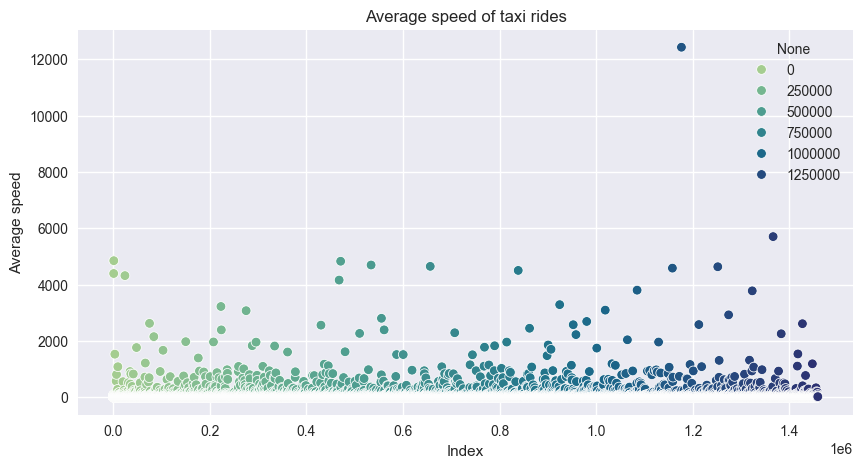

In [28]:
# Plot a scatter diagram of average vehicle speed to identify outliers and anomalies in the data

avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(x=avg_speed.index, y=avg_speed, ax=ax, hue=avg_speed.index, palette='crest')
ax.set_title('Average speed of taxi rides')
ax.set_xlabel('Index')
ax.set_ylabel('Average speed');

#experiment.log_figure('Average speed of taxi rides', plt)
plt.show();

This reveals "teleportation trips" with average speeds exceeding 1000 km/h, including one with an average speed over 12,000 km/h!

A maximum average speed of 300 km/h for taxi drivers will be assumed


Trips with a duration exceeding 24 hours will be identified and removed from the dataset.

a) The number of outliers based on trip duration will be calculated.

Trips with an average speed along the shortest path exceeding 300 km/h will be identified and removed from the data.

b) The number of outliers based on speed will be calculated.

In [29]:
# Create a function to identify and remove outliers from the dataset

def find_outliers(df):
    """
    Function removes outliers from the dataset based on trip duration and average speed.
    The function also removes unnecessary columns added for outlier analysis.
    
    Args:
        dataframe (pd.DataFrame): DataFrame from which outliers will be removed.

    Returns:
        dataframe (pd.DataFrame): DataFrame without outliers.
    """
    df['trip_in_hours'] = df['trip_duration'] / 60 / 60
    df['is_long_ride'] = df.apply(lambda x: 1 if x['trip_in_hours'] > 24 else 0, axis=1)
    ride_count_long = df[df['is_long_ride'] == 1]['id'].count()
    print(f'Number of trips longer than 24 hours: {ride_count_long}')
    
    df['avg_speed'] = df['total_distance'] / df['trip_duration'] * 3.6
    df['is_fast_ride'] = df.apply(lambda x: 1 if x['avg_speed'] > 300 else 0, axis=1)
    ride_count_fast = df[df['is_fast_ride'] == 1]['id'].count()
    print(f'Number of trips faster than 300 km/h: {ride_count_fast}')

    df = df[df['is_long_ride'] == 0]
    df = df[df['is_fast_ride'] == 0]
    
    column_to_drop = ['trip_in_hours', 'is_long_ride', 'avg_speed', 'is_fast_ride']
    df = df.drop(column_to_drop, axis=1)
    
    print(f'Dataset shape after removing outliers: {df.shape}')
    return df

# Remove outliers from the dataset

taxi_data = find_outliers(taxi_data)

Number of trips longer than 24 hours: 4
Number of trips faster than 300 km/h: 407
Dataset shape after removing outliers: (1458233, 26)


In [30]:
taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458233 entries, 0 to 1458643
Data columns (total 26 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   id                  1458233 non-null  object        
 1   vendor_id           1458233 non-null  int64         
 2   pickup_datetime     1458233 non-null  datetime64[ns]
 3   dropoff_datetime    1458233 non-null  object        
 4   passenger_count     1458233 non-null  int64         
 5   pickup_longitude    1458233 non-null  float64       
 6   pickup_latitude     1458233 non-null  float64       
 7   dropoff_longitude   1458233 non-null  float64       
 8   dropoff_latitude    1458233 non-null  float64       
 9   store_and_fwd_flag  1458233 non-null  object        
 10  trip_duration       1458233 non-null  int64         
 11  pickup_date         1458233 non-null  object        
 12  pickup_hour         1458233 non-null  int32         
 13  pickup_day_of_wee

## 3. Exploratory Data Analysis (EDA)

In this part of the project, the following will be performed:

- The formed dataset will be explored.

- Patterns that allow formulating preliminary hypotheses about which factors are decisive in determining trip duration will be identified.

- The analysis will be supplemented with visualizations illustrating the investigation. Visualizations will be created thoughtfully, as data visualization skills will be valuable in the future.

The analysis begins with the target variable. The primary evaluation metric for the task is `RMSLE (Root Mean Squared Log Error)`, which is calculated based on the target variable in logarithmic scale. Therefore, the trip duration feature will be logarithmized, and its logarithm will be considered as the target variable during analysis:

$$trip\_duration\_log = log(trip\_duration+1),$$

where log denotes the natural logarithm.

In [31]:
# Create a new feature trip_duration_log, representing the logarithm of trip duration

taxi_data['trip_duration_log'] = np.log(taxi_data['trip_duration']+1)

A histogram and boxplot of trip durations in logarithmic scale (`trip_duration_log`) will be plotted.

Based on the visualization, a hypothesis about whether the resulting distribution is normal will be formulated.

The hypothesis will be tested using the D’Agostino test at a significance level of $\alpha=0.05$. 

a) The calculated p-value will be determined

b) Whether the distribution of trip durations in logarithmic scale is normal will be assessed.

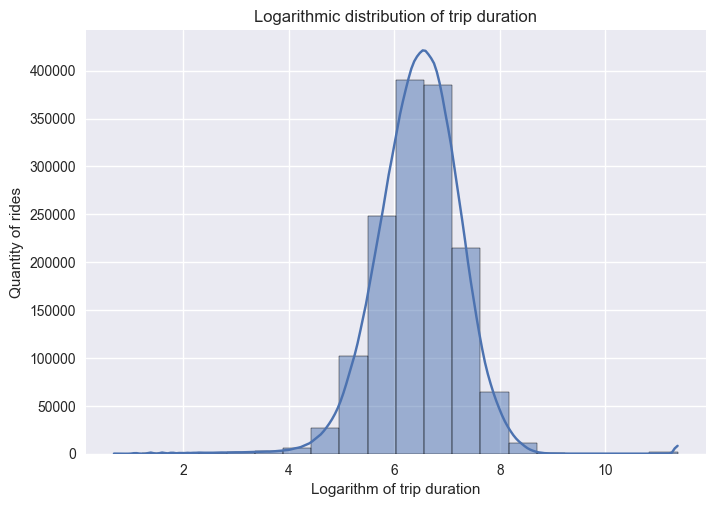

In [38]:
# Plot visualizations of trip durations in logarithmic scale

fig = sns.histplot(
    taxi_data['trip_duration_log'],
    bins=20,
    legend=True,
    kde=True
)

plt.ylabel('Quantity of rides')
plt.xlabel('Logarithm of trip duration')
plt.title('Logarithmic distribution of trip duration')
#experiment.log_figure('Logarithmic distribution of trip duration', plt)
plt.show();

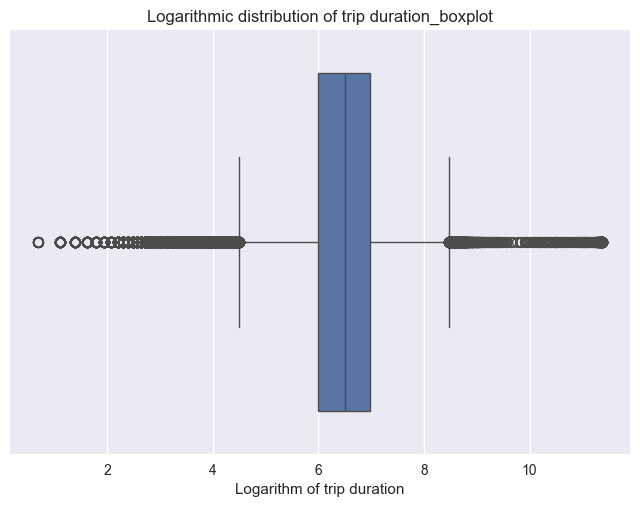

In [36]:
fig = sns.boxplot(
    x=taxi_data['trip_duration_log'],
    orient='h'
)

plt.xlabel('Logarithm of trip duration')
plt.title('Logarithmic distribution of trip duration_boxplot')
#experiment.log_figure('Logarithmic distribution of trip duration_boxplot', plt)
plt.show();

In [39]:
# Test the distribution for normality using the D'Agostino test

def test_d_agostino(df):
    """
    Function tests the data distribution for normality using the D'Agostino test.
    Args:
       dataframe (pd.DataFrame): DataFrame in which the data distribution will be tested.
    """
    stat, p_value = stats.normaltest(df['trip_duration_log'])
    
    # Интерпретация результата
    if p_value < 0.05:
        print('Distribution is not normal (reject the normality hypothesis). p-value =', p_value)
    else:
        print('Distribution is normal (do not reject the normality hypothesis). p-value =', p_value)

# Test the distribution for normality

test_d_agostino(taxi_data)

Distribution is not normal (reject the normality hypothesis). p-value = 0.0


- The histogram and the boxplot reveals that the distribution is not normalized.

- This result is confirmed by the D'Agostino test.

A visualization will be plotted to compare the distribution of trip duration in logarithmic scale (`trip_duration_log`) across taxi companies (`vendor_id`).

The two distributions will be compared.

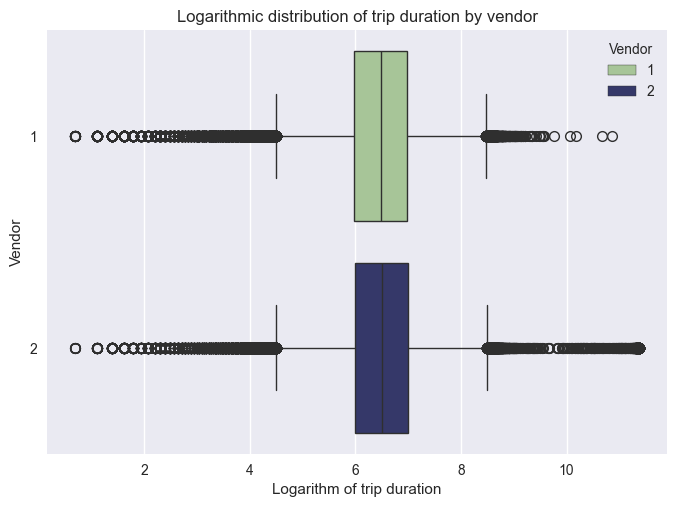

In [40]:
# Plot a visualization to examine trip duration in logarithmic scale by taxi company

fig = sns.boxplot(
    x=taxi_data['trip_duration_log'],
    y=taxi_data['vendor_id'],
    orient='h',
    hue=taxi_data['vendor_id'],
    palette='crest'
)

plt.legend(title='Vendor')
plt.xlabel('Logarithm of trip duration')
plt.ylabel('Vendor')
plt.title('Logarithmic distribution of trip duration by vendor')

#experiment.log_figure('Logarithmic distribution of trip duration by vendor', plt)
plt.show();

Overall, the distribution is similar for each taxi company, but the second company shows more outliers on the right side.

A visualization will be plotted to compare the distribution of trip duration in logarithmic scale `trip_duration_log` based on the `store_and_fwd_flag` feature.

The two distributions will be compared.

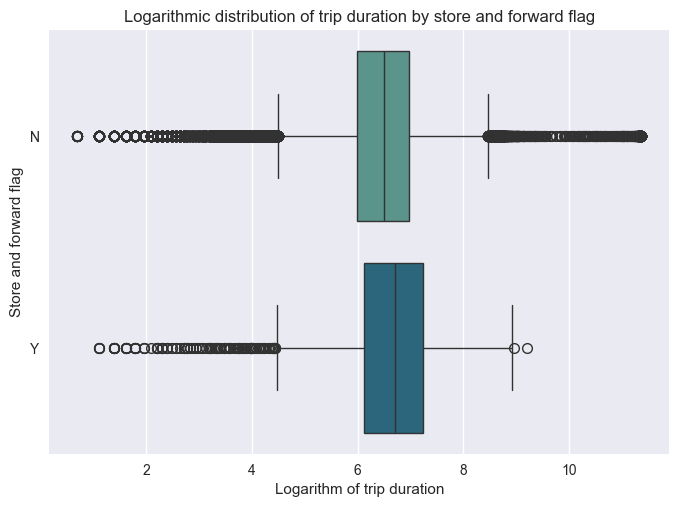

In [41]:
# Plot a visualization to examine trip duration in logarithmic scale based on message forwarding to the vendor

fig = sns.boxplot(
    x=taxi_data['trip_duration_log'],
    y=taxi_data['store_and_fwd_flag'],
    orient='h',
    hue=taxi_data['store_and_fwd_flag'],
    palette='crest'
)

plt.xlabel('Logarithm of trip duration')
plt.ylabel('Store and forward flag')
plt.title('Logarithmic distribution of trip duration by store and forward flag')

#experiment.log_figure('Logarithmic distribution of trip duration by store and forward flag',plt)
plt.show();

When messages are forwarded to the vendor, trips tend to be longer. This may be related to connectivity issues or delays in data transmission affecting trip logging.

Two visualizations will be plotted:

- Distribution of trip counts by hour of the day.

- Dependency of median trip duration on the hour of the day.

Based on the plotted graphs, the following questions will be answered:

a) At what time of day are taxis ordered the least?

b) At what time of day does the median trip duration peak?

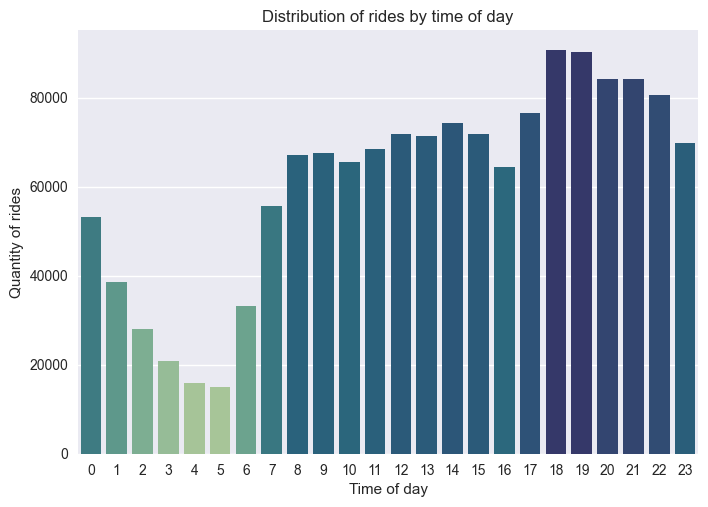

In [42]:
# Plot a visualization of trip distribution by hour of the day

bar_data = taxi_data.groupby('pickup_hour', as_index=False)['id'].count()

fig = sns.barplot(
    data=bar_data,
    x='pickup_hour',
    y='id',
    hue='id',
    palette='crest'
)

plt.xlabel('Time of day')
plt.ylabel('Quantity of rides')
plt.title('Distribution of rides by time of day')
plt.legend().remove()

#experiment.log_figure('Distribution of rides by time of day',plt)
plt.show();

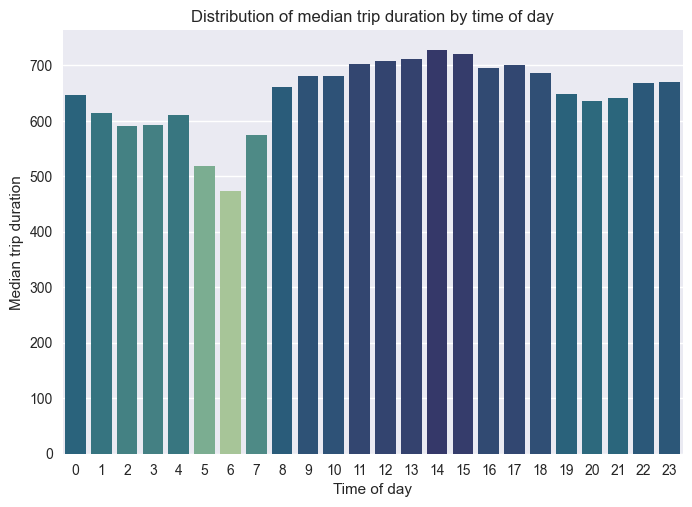

In [44]:
# Plot a visualization of median trip duration distribution by hour of the day

bar_data = taxi_data.groupby('pickup_hour', as_index=False)['trip_duration'].median()

fig = sns.barplot(
    data=bar_data,
    x='pickup_hour',
    y='trip_duration',
    hue='trip_duration',
    palette='crest'
)

plt.xlabel('Time of day')
plt.ylabel('Median trip duration')
plt.title('Distribution of median trip duration by time of day')
plt.legend().remove()

#experiment.log_figure('Distribution of median trip duration by time of day',plt)
plt.show();

### From the graphs, the following is observed:

- The fewest trips occur at night and early morning.

- Trip counts begin to increase in the morning, peaking in the evening after the workday ends.

- Median trip duration decreases at night, possibly due to fewer traffic jams, and increases during the day, peaking in the afternoon.

Two visualizations will be plotted:

- Distribution of trip counts by day of the week.

- Dependency of median trip duration on the day of the week.

Based on the plotted graphs, the following questions will be answered:

a) On which day of the week are the most trips made?

b) On which day of the week is the median trip duration the shortest?


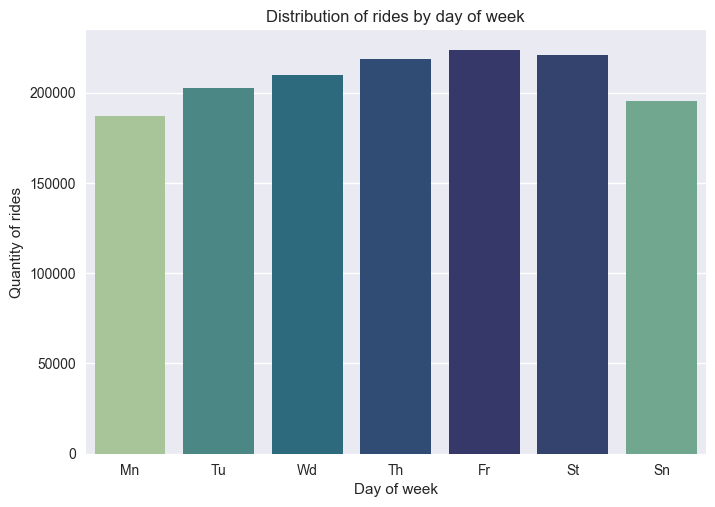

In [45]:
# Plot a visualization of trip distribution by day of the week

bar_data = taxi_data.groupby('pickup_day_of_week', as_index=False)['id'].count()

fig = sns.barplot(
    data=bar_data,
    x='pickup_day_of_week',
    y='id',
    hue='id',
    palette='crest'
)

plt.xlabel('Day of week')
plt.ylabel('Quantity of rides')
plt.title('Distribution of rides by day of week')
plt.xticks(
    ticks=range(7), 
    labels=['Mn', 'Tu', 'Wd', 'Th', 'Fr', 'St', 'Sn'],
)
plt.legend().remove()

#experiment.log_figure('Distribution of rides by day of week',plt)
plt.show();

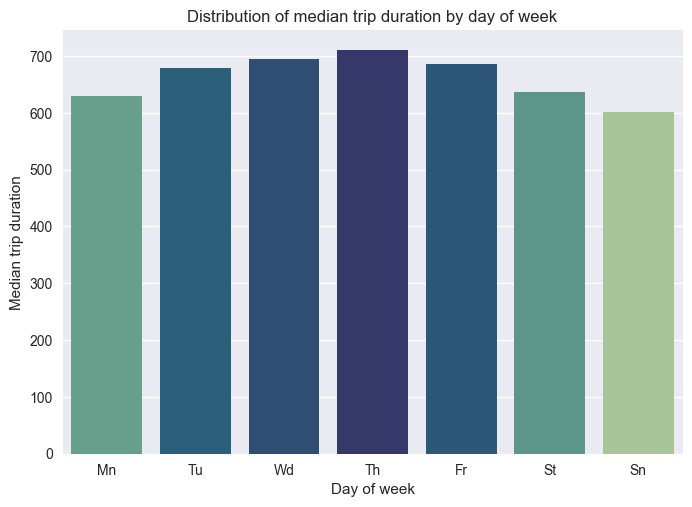

In [46]:
# Plot a visualization of median trip duration distribution by day of the week

bar_data = taxi_data.groupby('pickup_day_of_week', as_index=False)['trip_duration'].median()

fig = sns.barplot(
    data=bar_data,
    x='pickup_day_of_week',
    y='trip_duration',
    hue='trip_duration',
    palette='crest'
)

plt.xlabel('Day of week')
plt.ylabel('Median trip duration')
plt.title('Distribution of median trip duration by day of week')
plt.xticks(
    ticks=range(7), 
    labels=['Mn', 'Tu', 'Wd', 'Th', 'Fr', 'St', 'Sn'],
)
plt.legend().remove()

#experiment.log_figure('Distribution of median trip duration by day of week',plt)
plt.show();

### From the graphs, the following conclusions are drawn:

- The fewest taxis are ordered on Monday and Sunday; starting from Tuesday, the number of orders increases, peaking on Friday.

- The shortest median trip durations occur on Sunday, while the longest occur on Thursday.

Both temporal characteristics will be examined simultaneously.

A pivot table will be created, with hours (`pickup_hour`) as rows, days of the week (`pickup_day_of_week`) as columns, and median trip duration (`trip_duration`) as values.

The resulting pivot table will be visualized using a heatmap

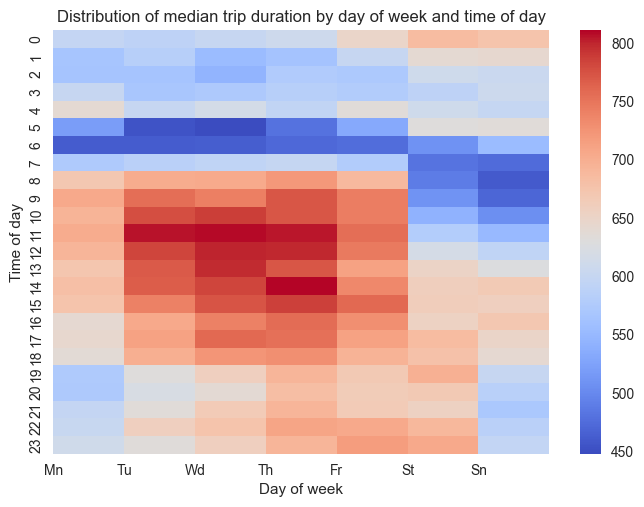

In [47]:
# Visualize both temporal characteristics using a heatmap

pivot_data = taxi_data.pivot_table(
    values='trip_duration',
    index='pickup_hour',
    columns='pickup_day_of_week',
    aggfunc='median'
)

heatmap = sns.heatmap(
    pivot_data,
    cmap='coolwarm',
)

plt.title('Distribution of median trip duration by day of week and time of day')
plt.xlabel('Day of week')
plt.ylabel('Time of day')
plt.xticks(
    ticks=range(7), 
    labels=['Mn', 'Tu', 'Wd', 'Th', 'Fr', 'St', 'Sn'],
)

#experiment.log_figure('Distribution of median trip duration by day of week and time of day',plt)
plt.show;

### From the heatmap, the following is observed:

- Confirmation that trip durations are shorter at night and on Sundays.

- Trip durations increase starting in the morning.

- Peaks in trip duration occur mid-day from Wednesday to Friday, possibly due to a high volume of business trips during these times.

Two scatter plots will be plotted:

- The first will illustrate the geographical locations of trip start points (`pickup_longitude`, `pickup_latitude`).

- The second will illustrate the geographical locations of trip end points (`dropoff_longitude`, `dropoff_latitude`).

For these plots, longitude will be plotted on the x-axis and latitude on the y-axis. Only points within New York City will be included, using the following axis boundaries:

`city_long_border` = (-74.03, -73.75)

`city_lat_border` = (40.63, 40.85)

The plots will be colored by the ten geographical clusters (`geo_cluster`) generated earlier.

Reduce the size of the points on the scatter plots for better clarity.

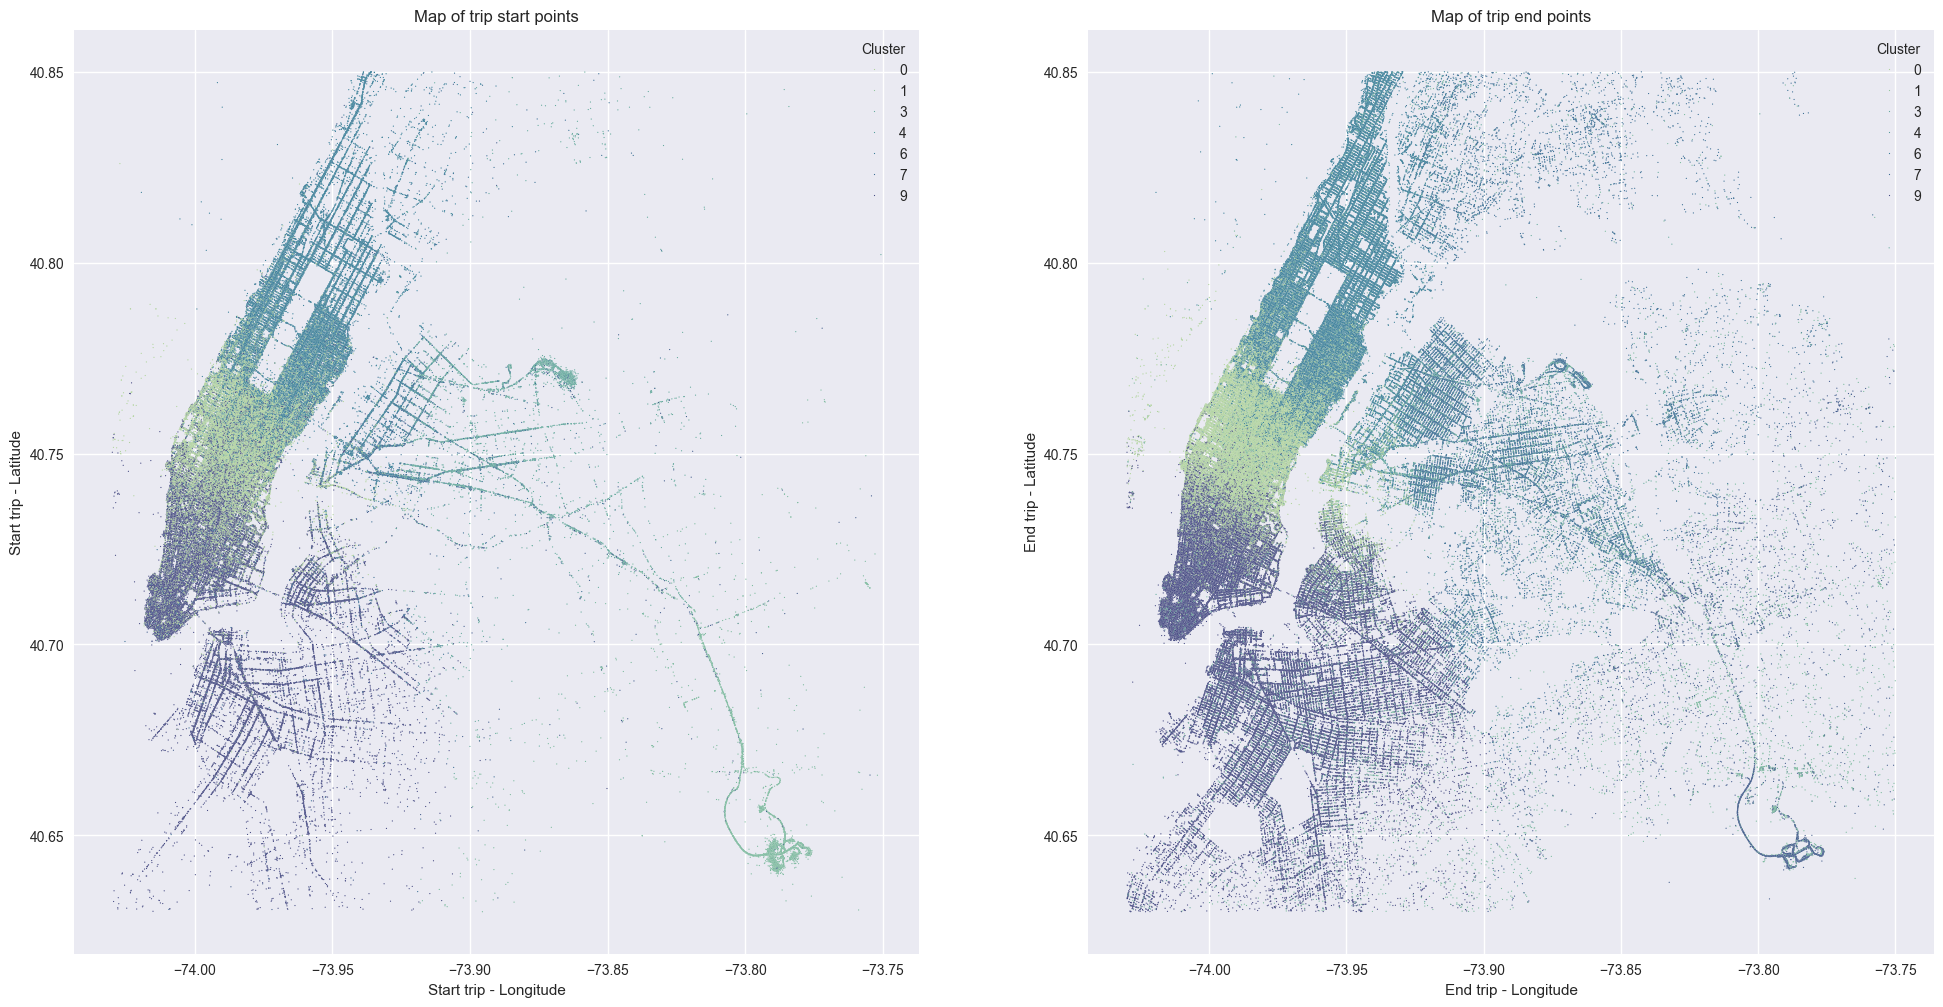

In [48]:
# Visualize the geographical locations of trip start and end points
# Define New York City boundaries to include only points within the city limits

long_min, long_max = -74.03, -73.75
lat_min, lat_max = 40.63, 40.85

mask_pickup = (
    taxi_data['pickup_longitude'].between(long_min, long_max) &
    taxi_data['pickup_latitude'].between(lat_min, lat_max)
)
mask_dropoff = (
    taxi_data['dropoff_longitude'].between(long_min, long_max) &
    taxi_data['dropoff_latitude'].between(lat_min, lat_max)
)   

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24,12))
sns.scatterplot(
    data=taxi_data[mask_pickup],
    x='pickup_longitude',
    y='pickup_latitude',
    hue='geo_cluster',
    palette='crest',
    s=0.75,
    ax = ax[0]
)

sns.scatterplot(
    data=taxi_data[mask_dropoff],
    x='dropoff_longitude',
    y='dropoff_latitude',
    hue='geo_cluster',
    palette='crest',
    s=0.75,
    ax = ax[1]
)

ax[0].legend(title='Cluster')
ax[0].set_title('Map of trip start points')
ax[0].set_xlabel('Start trip - Longitude')
ax[0].set_ylabel('Start trip - Latitude')
ax[1].legend(title='Cluster')
ax[1].set_title('Map of trip end points')
ax[1].set_xlabel('End trip - Longitude')
ax[1].set_ylabel('End trip - Latitude')

# experiment.log_figure('Map of trips', plt)
plt.show();

### From the data analysis, the following conclusions are drawn:

- The geography of trip start points is less extensive than that of end points, particularly noticeable in the northwest and west of the city.

- Most trips occur on Manhattan.

- A large number of trips go from Manhattan to other city boroughs.

- A high frequency of trips to what is likely an airport can be observed.

- Based on the clustering, three clusters fall outside the city boundaries, indicating these trips can be classified as intercity.

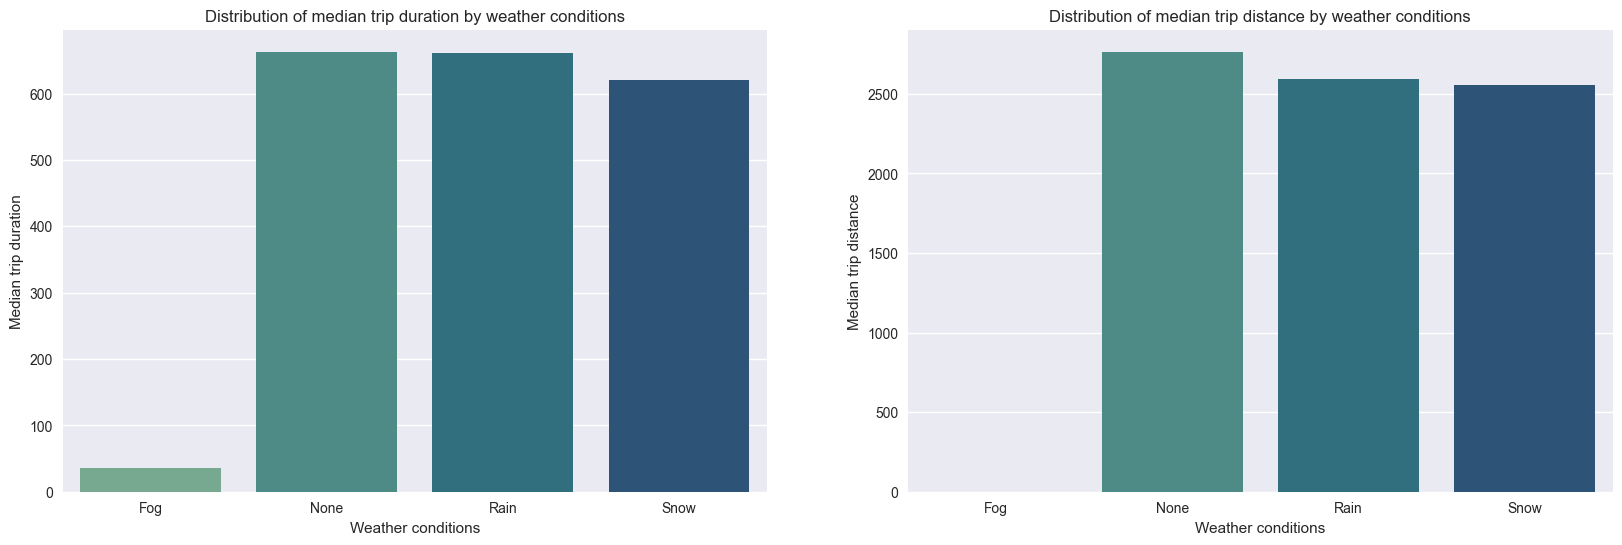

In [49]:
# Test the hypothesis that trips are longer and farther in bad weather

bar_data = taxi_data.groupby('events', as_index=False)['trip_duration'].median()
bar_data2 = taxi_data.groupby('events', as_index=False)['total_distance'].median()

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,6))

# Plot the visualization

sns.barplot(
    data=bar_data,
    x='events',
    y='trip_duration',
    hue='events',
    palette='crest',
    ax = ax[0],
    legend=False
)

sns.barplot(
    data=bar_data2,
    x='events',
    y='total_distance',
    hue='events',
    palette='crest',
    ax = ax[1],
    legend=False
)

ax[0].set_xlabel('Weather conditions')
ax[0].set_ylabel('Median trip duration')
ax[0].set_title('Distribution of median trip duration by weather conditions')
ax[1].set_xlabel('Weather conditions')
ax[1].set_ylabel('Median trip distance')
ax[1].set_title('Distribution of median trip distance by weather conditions')

#experiment.log_figure('Distribution of median trip duration and distance by weather conditions', plt)
plt.show();


### After testing the bad weather hypothesis, the following is observed:

- Snowy weather does not affect trip duration or distance.

- In rainy weather, trip duration is higher than distance, suggesting more congested streets during these times.

- There is insufficient data for foggy weather.

## 4. Feature Selection and Transformation

Before proceeding to model building, a few additional steps will be performed:

- Categorical features, which many machine learning algorithms cannot process in their raw form, will be encoded.

- Features to be used for model training will be selected.

- Some features will be scaled and transformed to improve the convergence of models based on numerical methods.

In [50]:
# Check the dataset dimensions after all transformations

print('Shape of data: {}'.format(taxi_data.shape))
print('Columns: {}'.format(taxi_data.columns))

Shape of data: (1458233, 27)
Columns: Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_date', 'pickup_hour', 'pickup_day_of_week',
       'pickup_holiday', 'total_distance', 'total_travel_time',
       'number_of_steps', 'haversine_distance', 'direction', 'geo_cluster',
       'temperature', 'visibility', 'wind speed', 'precip', 'events',
       'trip_duration_log'],
      dtype='object')


For convenience, a copy of the original trip data table will be created:

In [51]:
# Create a copy of the dataset to preserve the original data

train_data = taxi_data.copy()
train_data.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,...,number_of_steps,haversine_distance,direction,geo_cluster,temperature,visibility,wind speed,precip,events,trip_duration_log
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,...,5.0,1.498521,99.970196,6,4.4,8.0,27.8,0.3,None,6.122493
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,...,6.0,1.805507,-117.153768,9,28.9,16.1,7.4,0.0,None,6.498282
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,...,16.0,6.385098,-159.680165,9,-6.7,16.1,24.1,0.0,None,7.661527
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,...,4.0,1.485498,-172.737700,9,7.2,16.1,25.9,0.0,None,6.063785
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,...,5.0,1.188588,179.473585,6,9.4,16.1,9.3,0.0,None,6.077642


Obvious uninformative and redundant features will be addressed immediately.

a) The feature that is unique for each trip and does not provide useful information for determining duration will be identified.

b) The feature in the training dataset that causes data leakage will be determined.

c) The features identified in points a) and b) will be removed from the original data table. The number of remaining columns will be calculated.

In [52]:
# Remove the uninformative feature and the feature that may cause data leakage

train_data = train_data.drop(['id', 'dropoff_datetime'], axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 25)


The features `id` & `dropoff_datetime` will be removed, as the former is entirely unique, and the latter may cause data leakage.

Since all necessary information has been extracted from the trip start date, these features will be removed as they are no longer needed.


In [53]:
# Remove unnecessary features

drop_columns = ['pickup_datetime', 'pickup_date']
train_data = train_data.drop(drop_columns, axis=1)
print('Shape of data:  {}'.format(train_data.shape))

Shape of data:  (1458233, 23)


The `vendor_id` feature in the `train_data` table will be encoded such that it equals 0 if the taxi company identifier is 1, and 1 otherwise.

The `store_and_fwd_flag` feature in the `train_data` table will be encoded such that it equals 0 if the flag is set to 'N', and 1 otherwise.

a) The mean of the encoded `vendor_id` column will be calculated

b) The mean of the encoded `store_and_fwd_flag` column will be calculated

In [54]:
# Encode the vendor_id & store_and_fwd_flag features

train_data['vendor_id'] = train_data.apply(lambda x: 1 if x['vendor_id'] != 1 else 0, axis=1)
train_data['store_and_fwd_flag'] = train_data.apply(lambda x: 1 if x['store_and_fwd_flag'] == 'Y' else 0, axis=1)

In [55]:
# Calculate the mean to verify the function implementation

mean_vendor_id = train_data['vendor_id'].mean()
mean_store_flag = train_data['store_and_fwd_flag'].mean()

print(f'Mean of the encoded vendor_id column: {mean_vendor_id:.2f}')
print(f'Mean of the encoded store_and_fwd_flag column: {mean_store_flag:.3f}')

Mean of the encoded vendor_id column: 0.53
Mean of the encoded store_and_fwd_flag column: 0.006


A table `data_onehot` will be created from the one-hot encoded features `pickup_day_of_week`, `geo_cluster`, and events in the `train_data` table using `OneHotEncoder` from the sklearn library. The parameter drop will be set to 'first' to remove the first binary column, avoiding redundant features.

The handle_unknown parameter will be set to '`ignore`' to ensure the code runs without errors if the test set contains values not present in the training set.

The `OneHotEncoder` will produce an unnamed numpy array, which will be converted back into a DataFrame for easier handling. The method `get_feature_names_out()` from the `OneHotEncoder` object will be used to obtain the names of the encoded columns in the format `<original column name>_<category name>`.

The resulting DataFrame `data_onehot` will contain the encoded categorical features `pickup_day_of_week`, `geo_cluster`, and `events`.

The number of binary columns generated through one-hot encoding will be determined


In [56]:
# Initialize the encoder and specify columns for transformation

categorical_cols = ['pickup_day_of_week', 'geo_cluster', 'events']

one_hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
data_onehot = one_hot_encoder.fit_transform(train_data[categorical_cols])

# Obtain encoded column names and create a DataFrame
column_names = one_hot_encoder.get_feature_names_out(categorical_cols)
data_onehot = pd.DataFrame(data_onehot.toarray(), columns=column_names)

In [57]:
# Check the dimensions of the encoded dataset

print('Shape of data:  {}'.format(data_onehot.shape))

Shape of data:  (1458233, 18)


In [58]:
# Add the encoded data to the main dataset and remove the original columns

train_data = pd.concat(
    [train_data.reset_index(drop=True).drop(categorical_cols, axis=1), data_onehot], 
    axis=1
)
print('Shape of data: {}'.format(train_data.shape))

Shape of data: (1458233, 38)


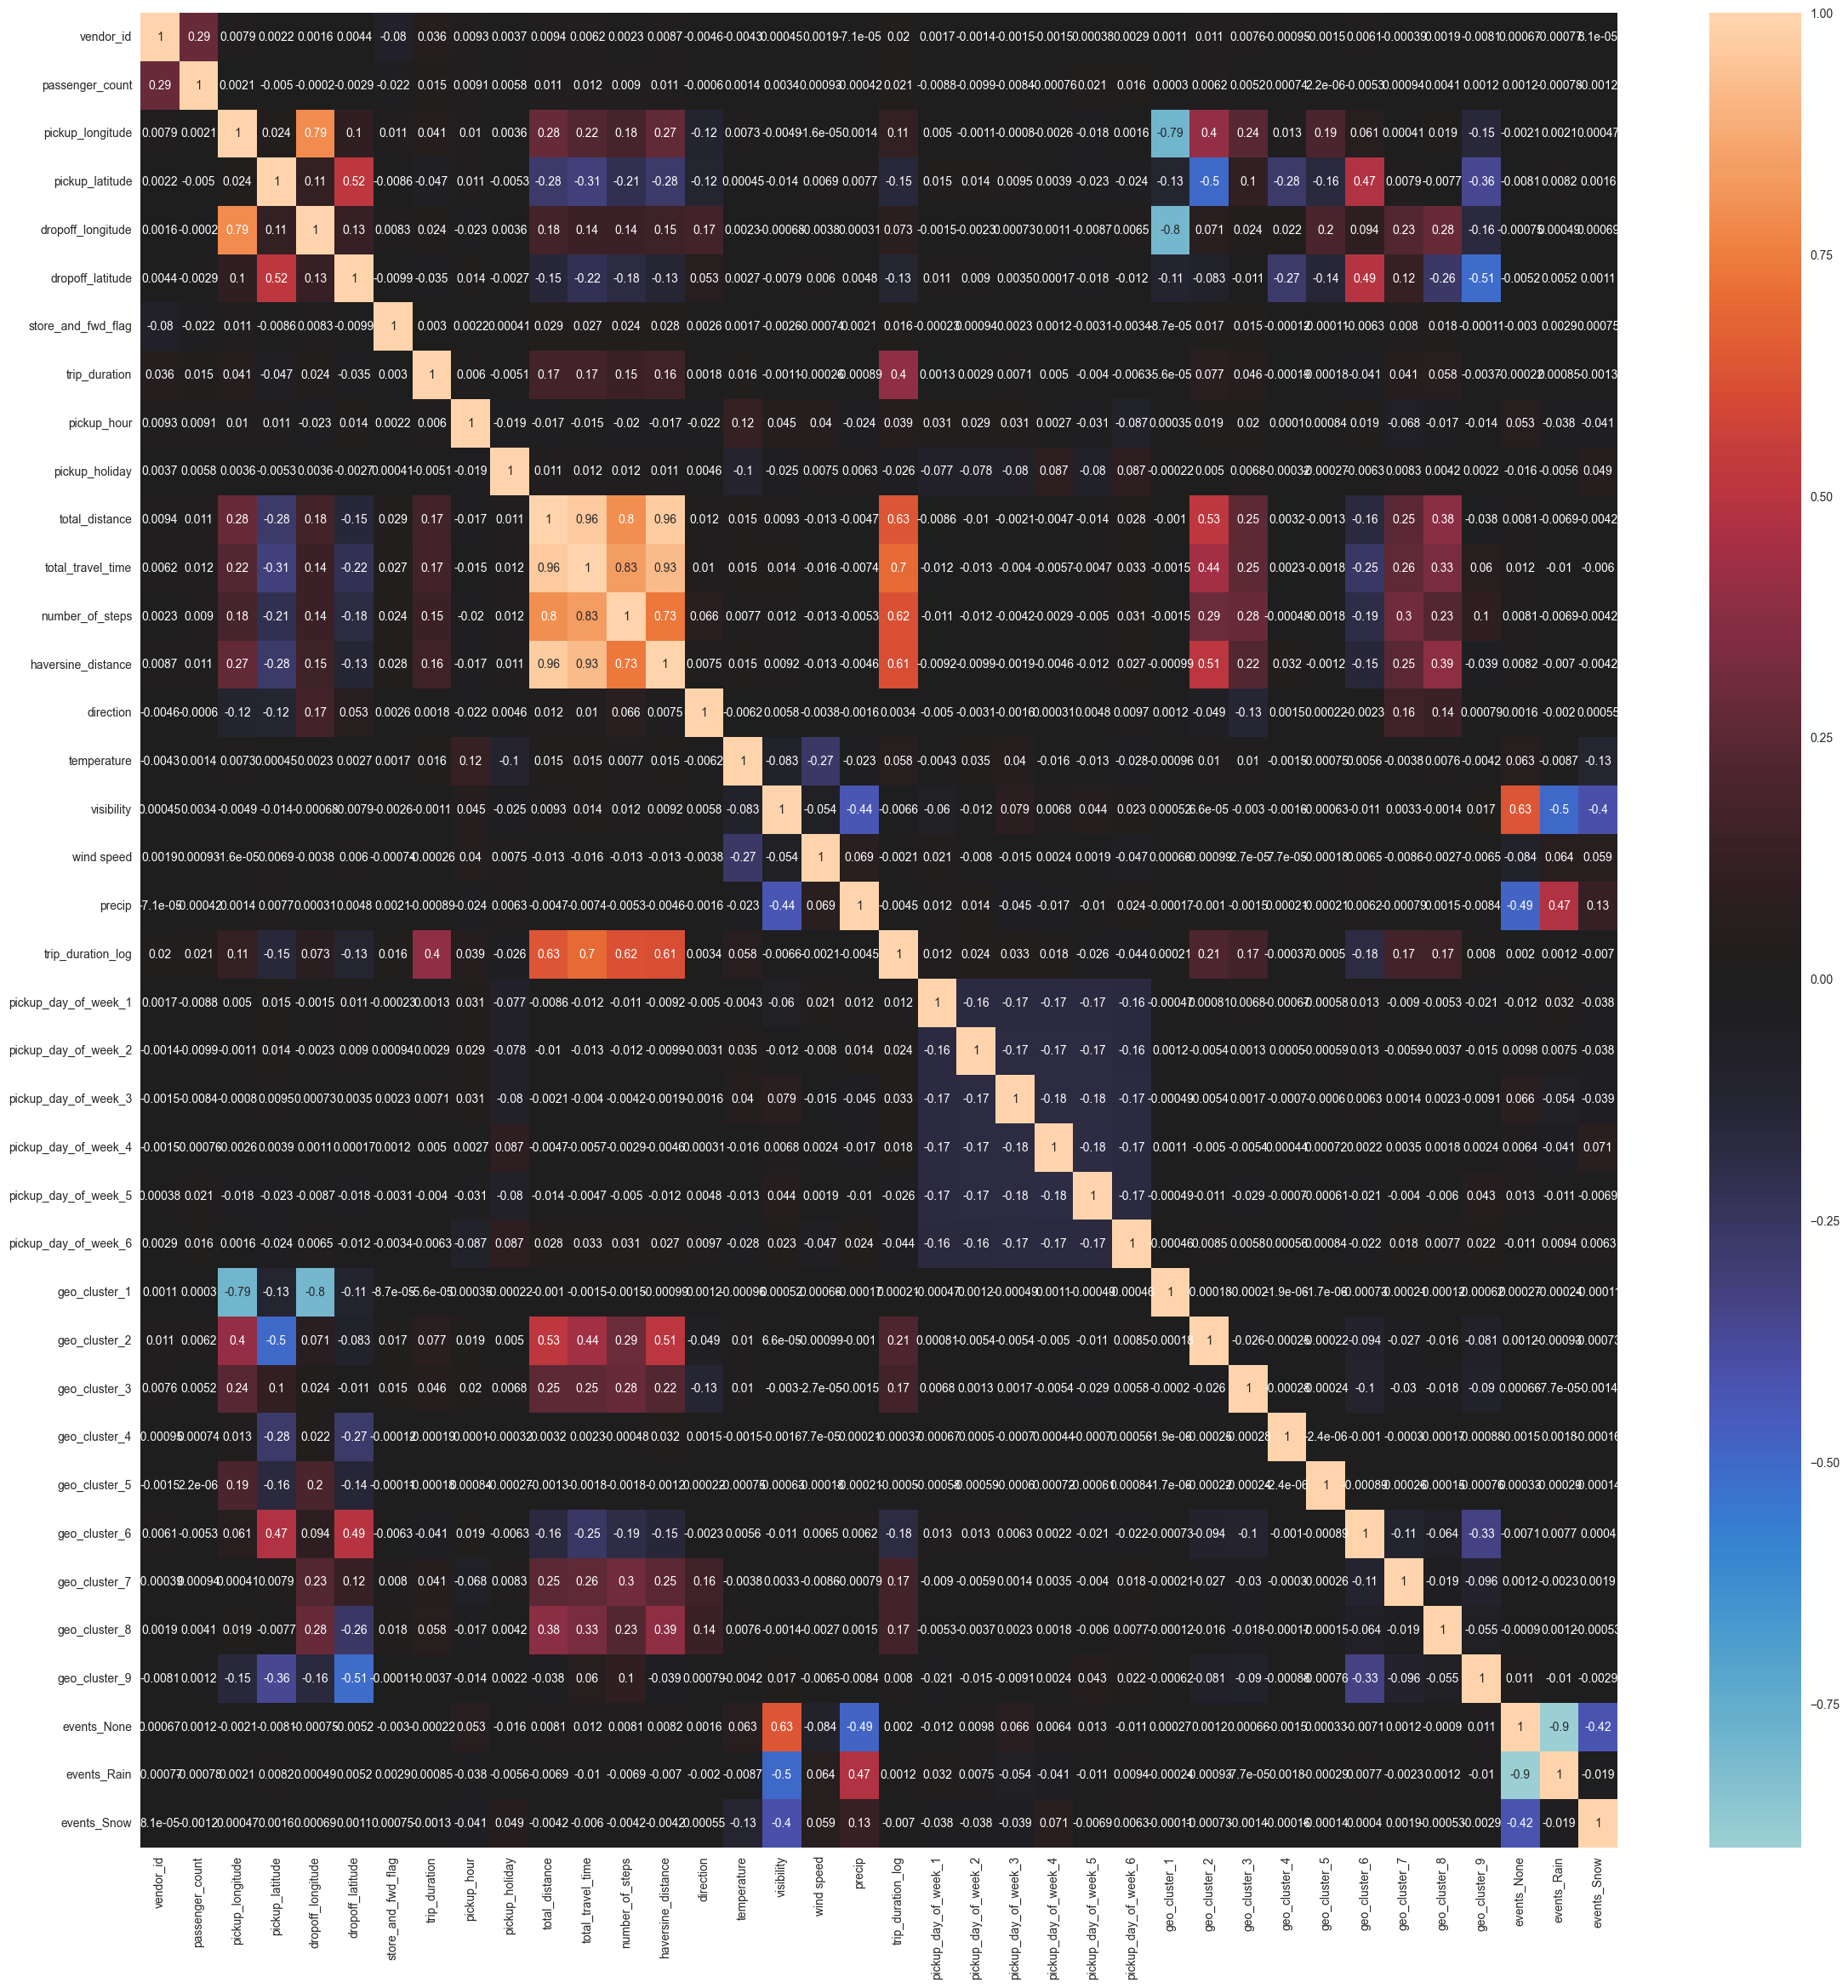

In [59]:
# Plot a correlation heatmap

plt.figure(figsize=(28,28))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, center=0);

#experiment.log_figure('Correlations', plt)
plt.show();

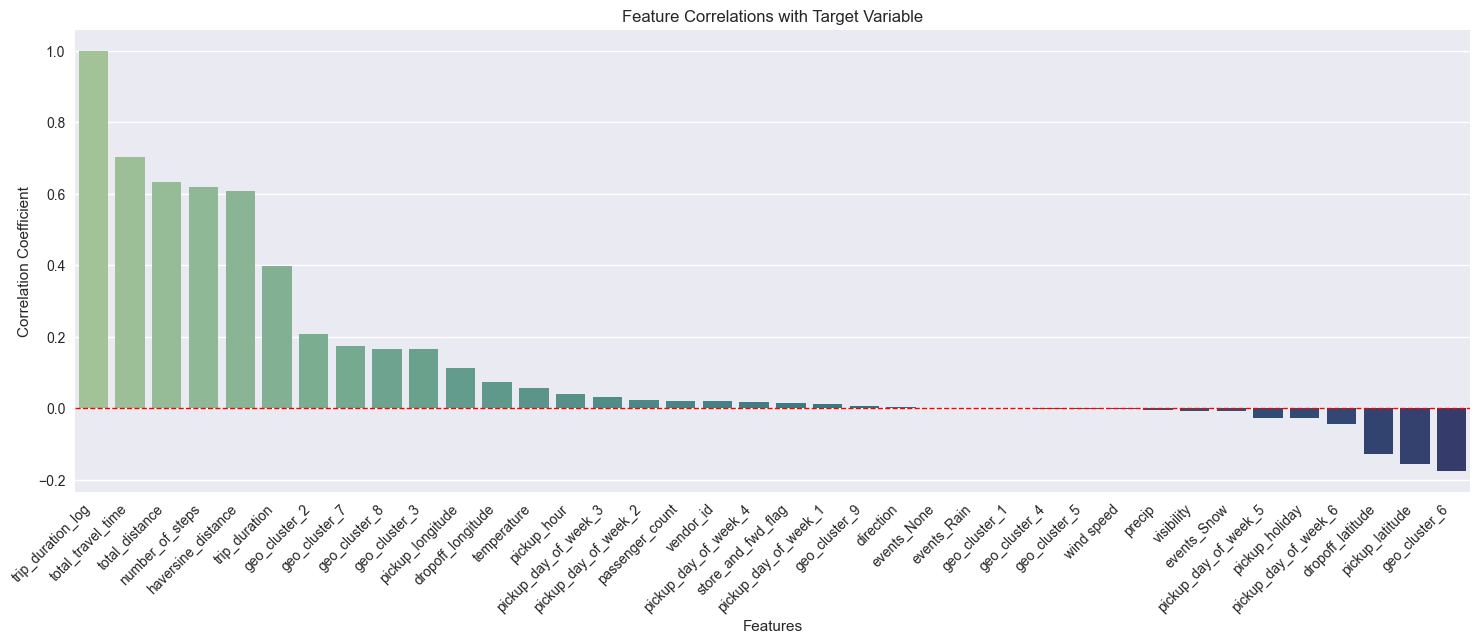

In [62]:
# Plot a bar chart of ranked correlation coefficients for the target feature

correlations = train_data.corr()['trip_duration_log']
sorted_correlations = correlations.sort_values(ascending=False)

plt.figure(figsize=(18, 6))
sns.barplot(
    x=sorted_correlations.index, 
    y=sorted_correlations.values, 
    palette='crest',
    hue=sorted_correlations.index,
    legend=False
)
plt.title('Feature Correlations with Target Variable')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xticks(rotation=45, ha='right')

#experiment.log_figure('Feature Correlations with Target Variable', plt)
plt.show();

There are no strong correlations `>0.7` between target variable and rest of the features

Now that categorical features have been preprocessed, the observation matrix X, target variable vector y, and its logarithm `y_log` will be formed. The observation matrix will include all columns from the trip data table except the target feature `trip_duration` and its logarithmized version `trip_duration_log`


In [63]:
# Create the training set

X = train_data.drop(['trip_duration', 'trip_duration_log'], axis=1)
y = train_data['trip_duration']
y_log = train_data['trip_duration_log']

All models will be trained on the logarithmized version `y_log`.

The chosen validation method is hold-out. The dataset will be split into training and validation sets in a **67/33 ratio**.

In [64]:
# Split the data into training and validation sets

X_train, X_valid, y_train_log, y_valid_log = model_selection.train_test_split(
    X, y_log, 
    test_size=0.33, 
    random_state=42
)

Currently, there are many features, and not all are likely to be important. Only those most strongly correlated with the target variable and certain to contribute to improving model quality will be retained.

Using `SelectKBest`, 25 features best suited for predicting the target variable in logarithmic scale will be selected. The selection will be performed on the training set using the parameter `score_func = f_regression`.

The features included in the selected list will be specified.

In [65]:
# Train and select the top 25 features suitable for prediction using the trained selector

selector = SelectKBest(
    k=25,
    score_func=f_regression
)

selector.fit(X_train, y_train_log)
best_features = selector.get_feature_names_out().tolist()
print(f'Features selected for further model building: \n {selector.get_feature_names_out()}')

# Transform the training and validation sets using the selector

X_train_selected = selector.transform(X_train)
X_valid_selected = selector.transform(X_valid)

Features selected for further model building: 
 ['vendor_id' 'passenger_count' 'pickup_longitude' 'pickup_latitude'
 'dropoff_longitude' 'dropoff_latitude' 'store_and_fwd_flag' 'pickup_hour'
 'pickup_holiday' 'total_distance' 'total_travel_time' 'number_of_steps'
 'haversine_distance' 'temperature' 'pickup_day_of_week_1'
 'pickup_day_of_week_2' 'pickup_day_of_week_3' 'pickup_day_of_week_4'
 'pickup_day_of_week_5' 'pickup_day_of_week_6' 'geo_cluster_2'
 'geo_cluster_3' 'geo_cluster_6' 'geo_cluster_7' 'geo_cluster_8']


Since various models, including those based on numerical optimization methods, will be used, predictors will be scaled in advance.

Predictors in the training and validation sets will be normalized using `MinMaxScaler` from the sklearn library. The scaler will be trained on the training set, and both the training and validation sets will be transformed.

The arithmetic mean of the first predictor (i.e., the first column of the matrix) in the validation set will be calculated

In [66]:
# Normalize the predictors

scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train_selected)
X_train_scaled = scaler.transform(X_train_selected)
X_valid_scaled = scaler.transform(X_valid_selected)

In [67]:
# Calculate the arithmetic mean for the first predictor

round(X_valid_scaled[:, 0].mean(),2)

0.54

## 5. Solving the Regression Task: Linear Regression and Decision Trees

The metric for evaluating model quality will be defined. Following the original Kaggle competition, the `RMSLE (Root Mean Squared Log Error)` metric will be used, calculated as:

$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2},$$

where:

- $y_i$: True duration of the i-th taxi trip (`trip_duration`).
- $\hat{y_i}$: Model-predicted duration of the i-th taxi trip.

Since the target feature has already been logarithmized, it will suffice to compute the RMSE metric for a model trained to predict taxi trip duration in logarithmic scale:

$$z_i=log(y_i+1),$$
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(z_i-\hat{z_i})^2}=\sqrt{MSE(z_i,\hat{z_i})}$$ 



A linear regression model will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). All parameters will be left at their default values.

The RMSLE metric will be calculated for the resulting model on the training and validation sets


In [68]:
# Build a linear regression model with default parameters

model = linear_model.LinearRegression()
model.fit(X_train_scaled, y_train_log)
y_pred_train_lr = model.predict(X_train_scaled)
y_pred_valid_lr = model.predict(X_valid_scaled)

# Calculate the RMSE metric on the training and validation sets

rsme_train_lr = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_lr),2)
rsme_valid_lr = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_lr),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_lr}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_lr}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_lr)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_lr)

Root Mean Squared Error for the training set: 0.54
Root Mean Squared Error for the validation set: 0.54


Polynomial features of degree 2 will be generated using `PolynomialFeatures` from the sklearn library. The parameter `include_bias` will be set to False.

A polynomial regression model of degree 2 will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). All parameters will be left at their default values.

a) The RMSLE metric will be calculated for the resulting model on the training and validation sets

b) Whether the model shows signs of overfitting will be assessed.

In [69]:
# Generate polynomial features of degree 2

poly = preprocessing.PolynomialFeatures(2, include_bias=False)

poly.fit(X_train_scaled)
X_train_poly = poly.transform(X_train_scaled)
X_valid_poly = poly.transform(X_valid_scaled)

# Train the model

model = linear_model.LinearRegression()
model.fit(X_train_poly, y_train_log)
y_pred_train_poly = model.predict(X_train_poly)
y_pred_valid_poly = model.predict(X_valid_poly)

# Calculate the RMSE metric on the training and validation sets

rsme_train_poly = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_poly),2)
rsme_valid_poly = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_poly),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_poly}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_poly}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_poly)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_poly)

Root Mean Squared Error for the training set: 0.47
Root Mean Squared Error for the validation set: 0.69


#### **Overfitting is present; regularization is needed**

A polynomial regression model of degree 2 with L2 regularization (Ridge regularization) will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). The regularization coefficient $\alpha$ will be set to 1, with all other parameters left at their default values.

The RMSLE metric will be calculated for the resulting model on the training and validation sets


In [70]:
# Build a polynomial regression model of degree 2 with L2 regularization

poly = preprocessing.PolynomialFeatures(2, include_bias=False)

poly.fit(X_train_scaled)
X_train_poly = poly.transform(X_train_scaled)
X_valid_poly = poly.transform(X_valid_scaled)

# Train the model

model = linear_model.Ridge(alpha=1)
model.fit(X_train_poly, y_train_log)
y_pred_train_poly_ridge = model.predict(X_train_poly)
y_pred_valid_poly_ridge = model.predict(X_valid_poly)

# Calculate the RMSE metric on the training and validation sets

rsme_train_ridge = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_poly_ridge),2)
rsme_valid_ridge = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_poly_ridge),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_ridge}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_ridge}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_ridge)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_ridge)

Root Mean Squared Error for the training set: 0.48
Root Mean Squared Error for the validation set: 0.48


A decision tree model (`DecisionTreeRegressor`) will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). All parameters will be left at their default values.

a) The RMSLE metric will be calculated for the resulting model on the training and validation sets

b) Whether the model shows signs of overfitting will be assessed.

In [71]:
# Build a decision tree model with default parameters

model = tree.DecisionTreeRegressor(random_state=42)

model.fit(X_train_scaled, y_train_log)
y_pred_train_tree = model.predict(X_train_scaled)
y_pred_valid_tree = model.predict(X_valid_scaled)

# Calculate the RMSE metric on the training and validation sets

rsme_train_tree = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_tree),2)
rsme_valid_tree = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_tree),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_tree}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_tree}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_tree)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_tree)

Root Mean Squared Error for the training set: 0.0
Root Mean Squared Error for the validation set: 0.56


#### **Overfitting is present; the tree depth will be specified**

### Задание 5.5.
All possible decision tree depths in the range from 7 to 20 will be iterated:

`max_depths` = range(7, 20)

The `random_state` parameter will be set to 42.

Line plots of the RMSE metric changes on the training and validation sets will be plotted based on the decision tree depth parameter.

a) The optimal maximum tree depth that yields the minimum RMSLE on the training set without overfitting (where the validation curve does not yet start to increase) will be identified.

b) The RMSLE metric values on the training and validation sets for the decision tree with the selected optimal depth will be calculated


In [72]:
# Create a function to iterate over decision tree depths

def find_max_depth():
    """
    Function iterates over maximum decision tree depths from 7 to 20 and calculates RMSE for each depth.

    Returns:
        errors (dict): Dictionary where the key is the maximum tree depth, and the value is a list of RMSE for the training and validation sets.
    """
    errors = dict()
    max_depths = range(7,20)
    for depth in max_depths:
        model = tree.DecisionTreeRegressor(random_state=42, max_depth=depth)
        model.fit(X_train_scaled, y_train_log)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_valid = model.predict(X_valid_scaled)
        rmse_train = round(metrics.root_mean_squared_error(y_train_log, y_pred_train),2)
        rmse_valid = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid),2)
        errors[depth] = [rmse_train, rmse_valid]
    
    return errors

# Record the results

errors = find_max_depth()

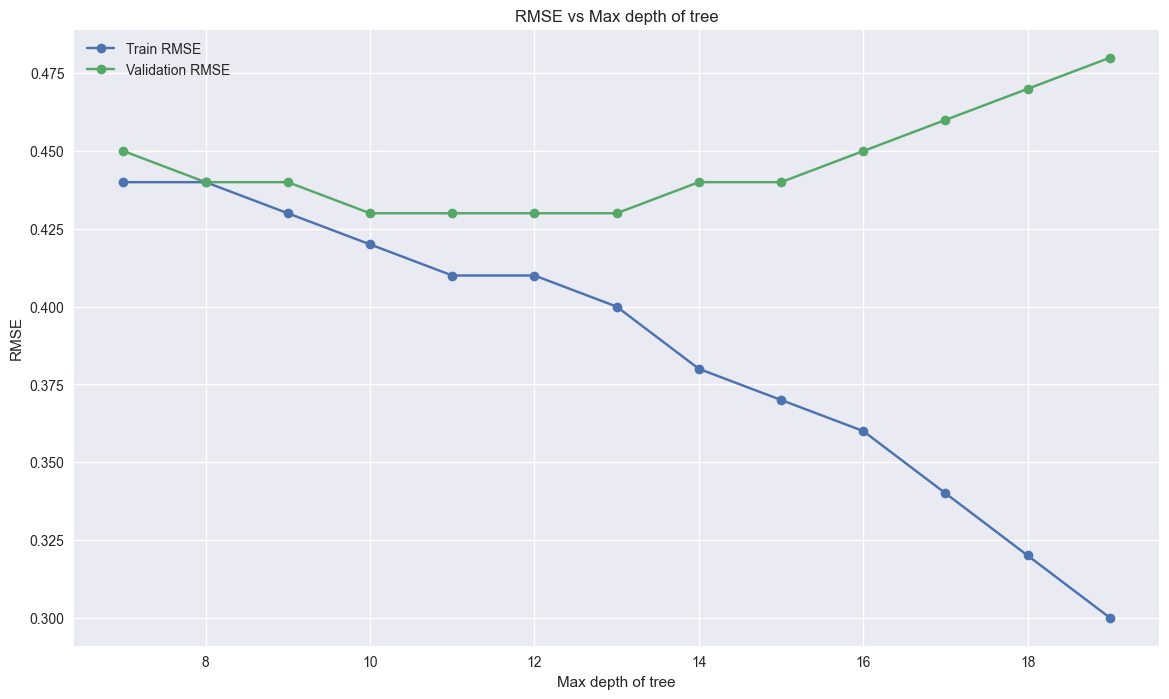

Best tree depth: 12
RMSE on training: 0.41
RMSE on validation: 0.43


In [73]:
# Create a DataFrame with the results

errors_df = pd.DataFrame.from_dict(errors, orient='index', columns=['RMSE_train', 'RMSE_valid'])
errors_df.index.name = 'max_depth'
errors_df.reset_index(inplace=True)

# Plot a graph to identify where overfitting begins

plt.figure(figsize=(14, 8))
plt.plot(errors_df['max_depth'], errors_df['RMSE_train'], label='Train RMSE', marker='o')
plt.plot(errors_df['max_depth'], errors_df['RMSE_valid'], label='Validation RMSE', marker='o')
plt.xlabel('Max depth of tree')
plt.ylabel('RMSE')
plt.title('RMSE vs Max depth of tree')
plt.legend()
plt.grid(True)

#experiment.log_figure('RMSE vs Max depth of tree', plt)
plt.show();

best = errors_df[errors_df['max_depth'] == 12].iloc[0]

print(
    f"Best tree depth: {int(best['max_depth'])}\n"
    f"RMSE on training: {best['RMSE_train']:.2f}\n"
    f"RMSE on validation: {best['RMSE_valid']:.2f}"
)

In [74]:
# Build a decision tree model using the previously found depth

model = tree.DecisionTreeRegressor(random_state=42, max_depth=12)

model.fit(X_train_scaled, y_train_log)
y_pred_train_tree_best = model.predict(X_train_scaled)
y_pred_valid_tree_best = model.predict(X_valid_scaled)

# Calculate the RMSE metric on the training and validation sets

rsme_train_tree_best = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_tree_best),2)
rsme_valid_tree_best = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_tree_best),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_tree_best}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_tree_best}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_tree_best)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_tree_best)

Root Mean Squared Error for the training set: 0.41
Root Mean Squared Error for the validation set: 0.43


## 6. Solving the Regression Task: Ensemble Methods and Prediction Building

A random forest model will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). The following hyperparameters will be specified:

- `n_estimators=200`,

- `max_depth=12`,

- `criterion='squared_error'`,

- `min_samples_split=20`,

- `random_state=42`

The RMSLE metric will be calculated for the resulting model on the training and validation sets.


In [75]:
# Build a random forest model

model = ensemble.RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    criterion='squared_error',
    min_samples_split=20,
    random_state=42,
    verbose=True
)

model.fit(X_train_scaled, y_train_log)
y_pred_train_ensemble = model.predict(X_train_scaled)
y_pred_valid_ensemble = model.predict(X_valid_scaled)

# Calculate the RMSE metric on the training and validation sets

rsme_train_ensemble = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_ensemble),2)
rsme_valid_ensemble = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_ensemble),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_ensemble}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_ensemble}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_ensemble)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_ensemble)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  6.3min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 26.9min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   20.8s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.8s


Root Mean Squared Error for the training set: 0.4
Root Mean Squared Error for the validation set: 0.41


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   10.4s


A gradient boosting model over decision trees (`GradientBoostingRegressor`) will be built on the training set (features must be normalized, and the target variable used in logarithmic scale). The following hyperparameters will be specified:

- `learning_rate=0.5`,

- `n_estimators=100`,

- `max_depth=6`,

- `min_samples_split=30`,

- `random_state=42`

The RMSLE metric will be calculated for the resulting model on the training and validation sets.

In [76]:
# Build a gradient boosting model over decision trees

model = ensemble.GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42,
    verbose=True
)

model.fit(X_train_scaled, y_train_log)
y_pred_train_gb = model.predict(X_train_scaled)
y_pred_valid_gb = model.predict(X_valid_scaled)

# Calculate the RMSE metric on the training and validation sets

rsme_train_gb = round(metrics.root_mean_squared_error(y_train_log, y_pred_train_gb),2)
rsme_valid_gb = round(metrics.root_mean_squared_error(y_valid_log, y_pred_valid_gb),2)

print(f'Root Mean Squared Error for the training set: {rsme_train_gb}')
print(f'Root Mean Squared Error for the validation set: {rsme_valid_gb}')

#experiment.log_metric('Root Meen Squered Error Train', rsme_train_gb)
#experiment.log_metric('Root Meen Squered Error Valid', rsme_valid_gb)

      Iter       Train Loss   Remaining Time 
         1           0.3110            8.44m
         2           0.2247            8.13m
         3           0.1987            8.02m
         4           0.1876            7.86m
         5           0.1823            7.77m
         6           0.1784            7.67m
         7           0.1752            7.65m
         8           0.1725            7.64m
         9           0.1713            7.66m
        10           0.1688            7.71m
        20           0.1599            7.11m
        30           0.1538            6.32m
        40           0.1505            5.64m
        50           0.1479            4.97m
        60           0.1453            4.13m
        70           0.1430            3.09m
        80           0.1415            2.04m
        90           0.1402            1.04m
       100           0.1382            0.00s
Root Mean Squared Error for the training set: 0.37
Root Mean Squared Error for the validation set: 

The model that achieved the best result (lowest RMSLE on the validation set) will be identified:
- Gradient Boosting over Decision Trees - **Best result: 0.37 on the training set and 0.39 on the validation set**

A bar chart of the importance coefficients for each feature will be plotted.

The top-3 most significant features for predicting the target variable — trip duration in logarithmic scale — will be identified.



 Топ 3 признака:
              Feature  Importance
9      total_distance    0.629706
10  total_travel_time    0.186361
7         pickup_hour    0.059159


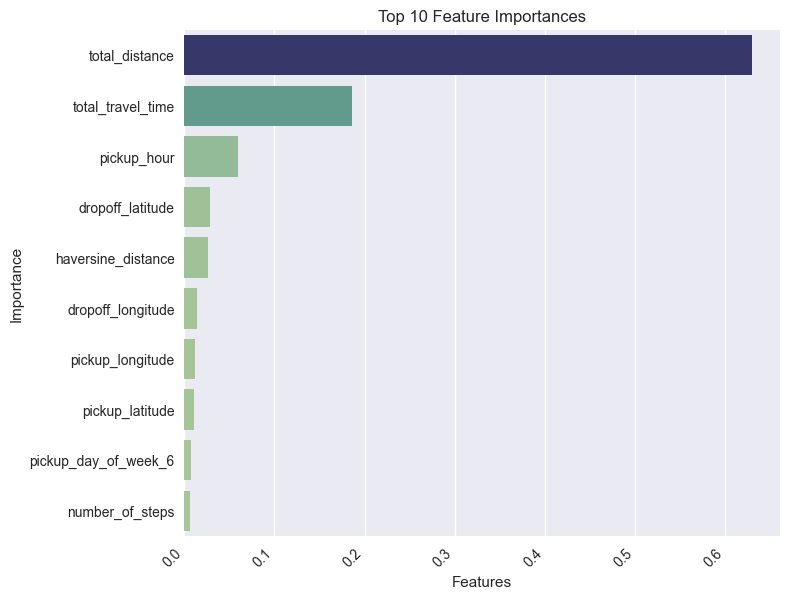

In [79]:
# Check if feature names are available

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_selected),
    columns=selector.get_feature_names_out()
)

feature_names = X_train_scaled.columns if isinstance(X_train_scaled, pd.DataFrame) else [f'Feature {i}' for i in range(X_train_scaled.shape[1])]

# Obtain feature importance
feature_importances = model.feature_importances_

# Create a DataFrame with feature names and their importance

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Select the three most important features

top_3_features = importance_df.head(3)

print("\n Топ 3 признака:")
print(top_3_features)

# Visualize feature importance

plt.figure(figsize=(8, 6))
sns.barplot(
    x=importance_df.head(10)['Importance'],
    y=importance_df.head(10)['Feature'],
    hue=importance_df.head(10)['Importance'],
    palette='crest',
    legend=False
)
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Features')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')

#experiment.log_figure('Top 10 Feature Importances', plt)
plt.show();

For the best model, the median absolute error (`MeAE`, available in sklearn as `median_absolute_error`) for predicting taxi trip duration on the validation set will be calculated:

$$ MeAE = median(|y_i-\hat{y_i}|)$$

The MeAE metric value will be converted to minutes and rounded to one decimal place.


In [80]:
# Calculate the median absolute error, converting predictions back from logarithmic scale

y_pred_train_orig = np.expm1(y_pred_train_gb)
y_train_orig = np.expm1(y_train_log)

y_pred_valid_orig = np.expm1(y_pred_valid_gb)
y_valid_orig = np.expm1(y_valid_log)

mae_train = round(metrics.median_absolute_error(y_train_orig, y_pred_train_orig),1)
mae_valid = round(metrics.median_absolute_error(y_valid_orig, y_pred_valid_orig),1)

print(f'Median Absolute Error for the training set: {mae_train / 60:.2f} minutes')
print(f'Median Absolute Error for the validation set: {mae_valid / 60:.2f} minutes')

# Calculate the RMSE metric on the training and validation sets

#experiment.log_metric('Median Absolute Error Train', mae_train)
#experiment.log_metric('Median Absolute Error Valid', mae_valid)

Median Absolute Error for the training set: 1.81 minutes
Median Absolute Error for the validation set: 1.84 minutes


The final step is to make a submission — predictions for the hold-out test dataset.

The test data will be read, and the column with trip identifiers from the test set will be extracted in advance for later use.


In [81]:
# Load the test data to evaluate the model

test_data = pd.read_csv("data/test_data.csv")
osrm_data_test = pd.read_csv("data/osrm_data_test.csv")
test_id = test_data['id']

Before generating predictions for the test set, all data manipulations performed on the training set must be applied, including:

- Converting the `pickup_datetime` feature to datetime format.

- Adding new features (`temporal, geographical, weather, and other factors`).

- Cleaning the data from missing values.

- Encoding categorical features:

- Encoding binary features.

- Encoding nominal features using the `OneHotEncoder` trained on the training set.

- Forming the observation matrix, retaining only the features selected by `SelectKBest`.

- Normalizing the data using the `MinMaxScaler` trained on the training set.


In [82]:
# Apply all transformations to test data 

test_data['pickup_datetime']=pd.to_datetime(test_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
test_data = add_datetime_features(test_data)
test_data = add_holiday_features(test_data, holiday_data)
test_data = add_osrm_features(test_data, osrm_data_test)
test_data = add_geographical_features(test_data)
test_data = add_cluster_features(test_data, kmeans)
test_data = add_weather_features(test_data, weather_data)
test_data = fill_null_weather_data(test_data)

test_data['vendor_id'] = test_data['vendor_id'].apply(lambda x: 0 if x == 1 else 1)
test_data['store_and_fwd_flag'] = test_data['store_and_fwd_flag'].apply(lambda x: 0 if x == 'N' else 1)
test_data_onehot = one_hot_encoder.fit_transform(test_data[categorical_cols]).toarray()
column_names = one_hot_encoder.get_feature_names_out(categorical_cols)
test_data_onehot = pd.DataFrame(test_data_onehot, columns=column_names)

test_data = pd.concat(
    [test_data.reset_index(drop=True).drop(categorical_cols, axis=1), test_data_onehot], 
    axis=1
)
X_test = test_data[best_features]
X_test_scaled = scaler.transform(X_test)
print('Shape of data: {}'.format(X_test.shape))

c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


Shape of data: (625134, 25)


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Only after completing these steps can predictions for trip duration on the test set be made. Predictions must be converted from logarithmic scale back to the true scale using the formula:

$$y_i=exp(z_i)-1$$

After generating predictions for trip durations on the test set, a submission file in CSV format will be created, submitted to the Kaggle platform, and the resulting RMSLE metric value on the test set will be evaluated.


In [83]:
# Make predictions on the test set

model = ensemble.GradientBoostingRegressor(
    learning_rate=0.5,
    n_estimators=100,
    max_depth=6,
    min_samples_split=30,
    random_state=42,
    verbose=True
)
model.fit(X_train_scaled, y_train_log)

y_pred_test = model.predict(X_test_scaled) 

# Convert back to the true scale
   
y_test_predict = np.expm1(y_pred_test) - 1          

print(f'Generated {len(y_test_predict)} predictions for the test set.')

      Iter       Train Loss   Remaining Time 
         1           0.3110            9.49m
         2           0.2247            8.96m
         3           0.1987            8.84m
         4           0.1876            8.93m
         5           0.1823            8.92m
         6           0.1784            8.94m
         7           0.1752            8.92m
         8           0.1725            8.89m
         9           0.1713            8.81m
        10           0.1688            8.80m
        20           0.1599            7.91m
        30           0.1538            6.80m
        40           0.1505            5.80m
        50           0.1479            4.87m
        60           0.1453            3.91m
        70           0.1430            2.93m
        80           0.1415            1.96m
        90           0.1402           59.63s
       100           0.1382            0.00s


c:\Users\ademidov\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


Generated 625134 predictions for the test set.


In [84]:
# creating the submission file, Write predictions to a file

submission = pd.DataFrame({'id': test_id, 'trip_duration': y_test_predict})
submission.to_csv('data/submission_gb.csv', index=False)

## **XGBoost**

To conclude the ensemble methods, an attempt to improve predictions using the Extreme Gradient Boosting (`XGBoost`) model from the xgboost library is proposed.

**XGBoost** is a modern machine learning model that extends Friedman’s gradient boosting concept. It offers several advantages over the classical gradient boosting model from sklearn: improved performance through parallelized training, enhanced solution quality due to an improved boosting algorithm, reduced overfitting tendency, and extensive functionality for managing model parameters.

In [85]:
# Import the model

import xgboost as xgb

Before training the model, the datasets must be converted to the `xgboost.DMatrix` type

In [86]:
# Create observation matrices in DMatrix format

dtrain = xgb.DMatrix(X_train_scaled, label=y_train_log, feature_names=best_features)
dvalid = xgb.DMatrix(X_valid_scaled, label=y_valid_log, feature_names=best_features)
dtest = xgb.DMatrix(X_test_scaled, feature_names=best_features)

Training the `XGBoost` model is performed using the train method, which requires specifying model parameters, the dataset, the number of base models in the ensemble, and additional parameters

In [87]:
# Model hyperparameters

xgb_pars = {'min_child_weight': 20, 'eta': 0.1, 'colsample_bytree': 0.9, 
            'max_depth': 6, 'subsample': 0.9, 'lambda': 1, 'nthread': -1, 
            'booster' : 'gbtree', 'eval_metric': 'rmse', 'objective': 'reg:squarederror'
           }

# Training and validation sets

watchlist = [(dtrain, 'train'), (dvalid, 'valid')]

# Train the XGBoost model

model = xgb.train(
    params=xgb_pars, # model hyperparameters
    dtrain=dtrain, # training set
    num_boost_round=300, # number of models in the ensemble
    evals=watchlist, # sets for metric calculation
    early_stopping_rounds=20, # early stopping
    maximize=False, # switch to minimize instead of maximize
    verbose_eval=10 # step for displaying metrics
)

[0]	train-rmse:0.73991	valid-rmse:0.74192
[10]	train-rmse:0.49085	valid-rmse:0.49344
[20]	train-rmse:0.44057	valid-rmse:0.44344
[30]	train-rmse:0.42636	valid-rmse:0.42938
[40]	train-rmse:0.41915	valid-rmse:0.42231
[50]	train-rmse:0.41351	valid-rmse:0.41692
[60]	train-rmse:0.40982	valid-rmse:0.41357
[70]	train-rmse:0.40721	valid-rmse:0.41130
[80]	train-rmse:0.40473	valid-rmse:0.40910
[90]	train-rmse:0.40290	valid-rmse:0.40761
[100]	train-rmse:0.40059	valid-rmse:0.40557
[110]	train-rmse:0.39921	valid-rmse:0.40445
[120]	train-rmse:0.39777	valid-rmse:0.40324
[130]	train-rmse:0.39623	valid-rmse:0.40204
[140]	train-rmse:0.39527	valid-rmse:0.40132
[150]	train-rmse:0.39411	valid-rmse:0.40042
[160]	train-rmse:0.39318	valid-rmse:0.39987
[170]	train-rmse:0.39223	valid-rmse:0.39917
[180]	train-rmse:0.39118	valid-rmse:0.39840
[190]	train-rmse:0.39019	valid-rmse:0.39794
[200]	train-rmse:0.38942	valid-rmse:0.39742
[210]	train-rmse:0.38851	valid-rmse:0.39683
[220]	train-rmse:0.38785	valid-rmse:0.39638

The target feature on new data can be predicted using the `predict()` method.

In [88]:
# Make predictions on the test dataset

y_test_predict = np.exp(model.predict(dtest)) - 1
print('Modeling RMSLE %.5f' % model.best_score)

Modeling RMSLE 0.39420


Like all models based on decision trees as base models, `XGBoost` allows for determining feature importance coefficients. Additionally, the library includes built-in functionality to visualize feature importance as a bar chart using the `plot_importance()` function

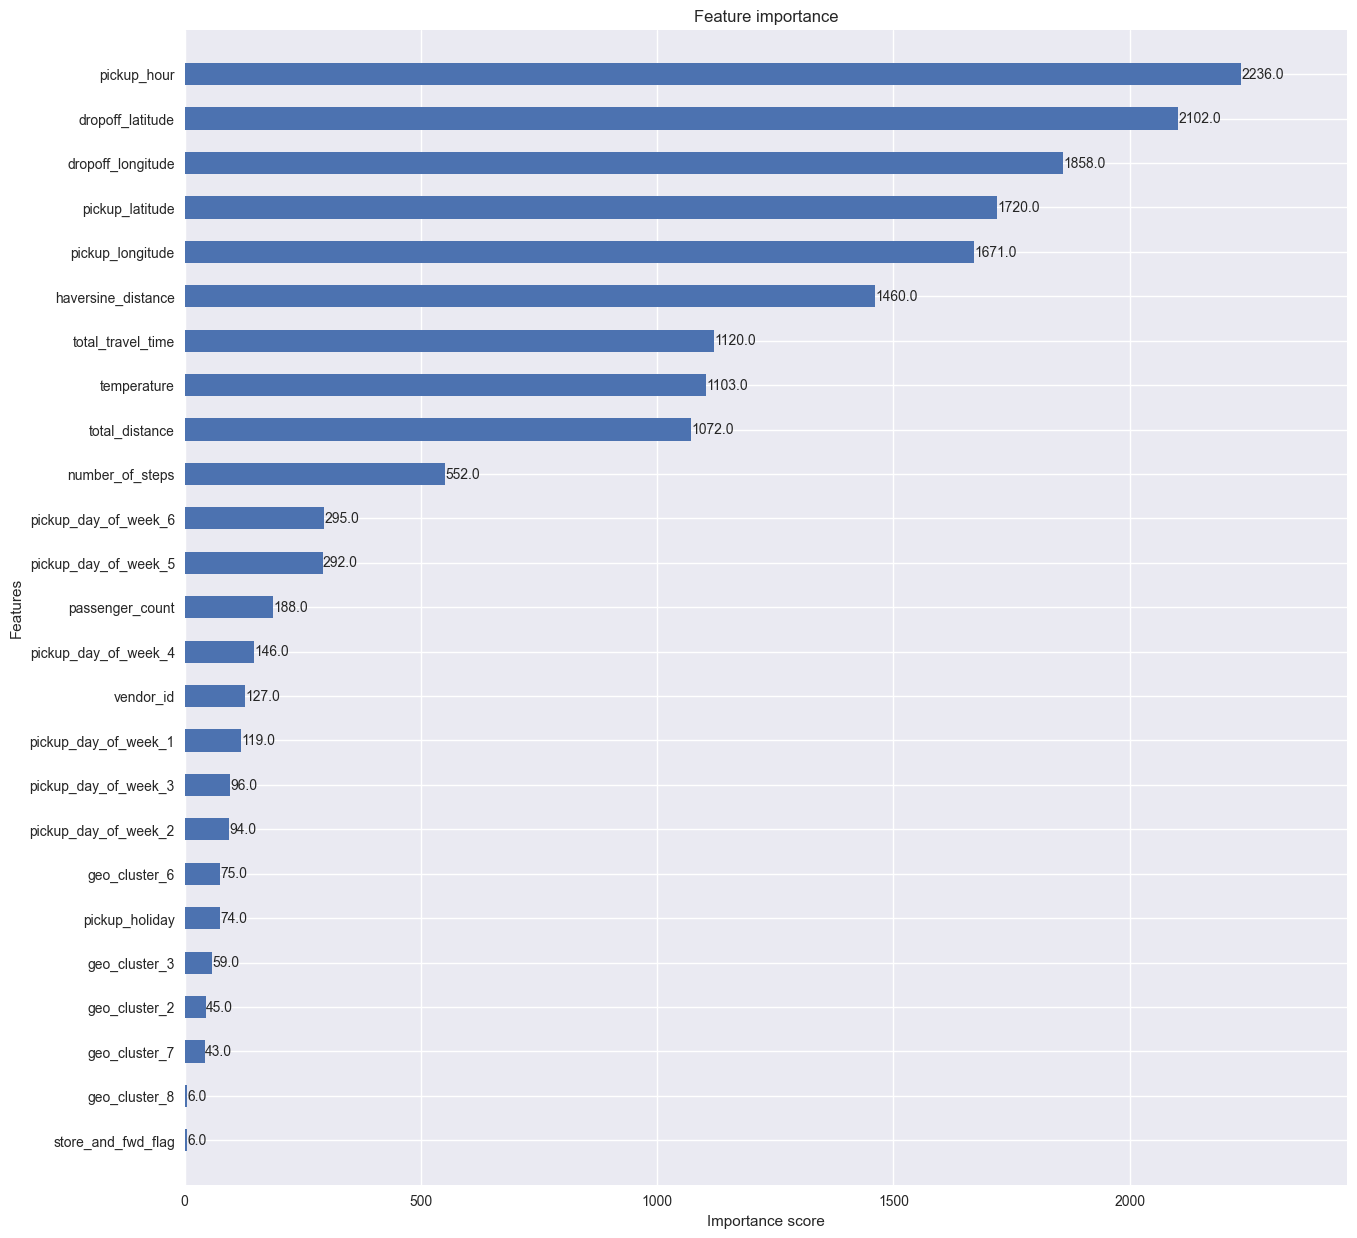

In [89]:
# Plot the feature importance graph

fig, ax = plt.subplots(figsize = (15,15))
xgb.plot_importance(model, ax = ax, height=0.5)

#experiment.log_figure('Important features xgb', plt)
plt.show();

In [90]:
# End the experiment

#experiment.end()